In [ ]:
import nbformat
from nbconvert import PythonExporter

notebook_path = '/content/drive/MyDrive/FWI/Forward_modelling.ipynb'
output_script_path = '/content/Forward_modelling.py'

with open(notebook_path, 'r', encoding='utf-8') as f:
    notebook_content = nbformat.read(f, as_version=4)
exporter = PythonExporter()
python_code, _ = exporter.from_notebook_node(notebook_content)
with open(output_script_path, 'w', encoding='utf-8') as f:
    f.write(python_code)

In [ ]:
import sys
sys.path.append('/content/Forward_modelling')



In [ ]:
import Forward_modelling

In [ ]:
from Forward_modelling import helmholtz5
from Forward_modelling import helmholtz9
from Forward_modelling import helmholtzabc
from Forward_modelling import analytic_2d_helmholtz


In [ ]:

import nbformat
from nbconvert import PythonExporter

notebook_path = '/content/drive/MyDrive/FWI/Inversion.ipynb'
output_script_path = '/content/Inversion.py'

with open(notebook_path, 'r', encoding='utf-8') as f:
    notebook_content = nbformat.read(f, as_version=4)
exporter = PythonExporter()
python_code, _ = exporter.from_notebook_node(notebook_content)
with open(output_script_path, 'w', encoding='utf-8') as f:
    f.write(python_code)

In [ ]:
sys.path.append('/content/Inversion')

In [ ]:
from Inversion import Gradient
from Inversion import Gauss_newton
from Inversion import Full_newton

In [ ]:
from Inversion import Hessian

In [ ]:
from Inversion import discrepancy_principle

In [ ]:
from Inversion import jackson_principle

In [ ]:
from Inversion import compute_gradient_field
from Inversion import compute_forward_adjoint_fields

In [ ]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter


In [ ]:
# ==========================================================
#  GRID
# ==========================================================
nx, nz =80, 80
dx = dz = 10
n = nx * nz
npml = 10

idx = lambda i, j: i * nx + j

# ==========================================================
# SOURCES & RECEIVERS
# ==========================================================
nsrc = 7
src_x = np.linspace(10, nx-15, nsrc).astype(int)
src_z = 2  ####for 10 result is good


# Receiver x positions
rec_x = np.arange(5, nx-5, 2)
rec_z = 0
#rec_idx = [idx(15,i) for i in range(10,70)]
rec_idx = [idx(rec_z, x) for x in rec_x]
nrec = len(rec_idx)


# Source physical positions

x_phys = np.arange(nx) * dx
z_phys = np.arange(nz) * dz

src_x_phys = src_x * dx
src_z_phys = src_z * dz

rec_x_phys = rec_x * dx
rec_z_phys = rec_z * dz

model_extent = [x_phys[0], x_phys[-1], z_phys[-1], z_phys[0]]
print("No of recievers" , nrec)
print("No of sources" , nsrc)


No of recievers 35
No of sources 7


In [ ]:
rec_x_phys

array([ 50,  70,  90, 110, 130, 150, 170, 190, 210, 230, 250, 270, 290,
       310, 330, 350, 370, 390, 410, 430, 450, 470, 490, 510, 530, 550,
       570, 590, 610, 630, 650, 670, 690, 710, 730])

In [ ]:
src_x_phys

array([100, 190, 280, 370, 460, 550, 650])

In [ ]:
# ==========================================================
# TRUE MODEL
# ==========================================================
c_true = 2000*np.ones((nz,nx))
c_true[30:50,30:50] = 2500
#c_true[6:8,7:10] = 2500

#c_true[4:, :] = 2500

c_init = 2000*np.ones_like(c_true)

m_true = 1/c_true**2
m = 1/c_init**2
vmax=2500

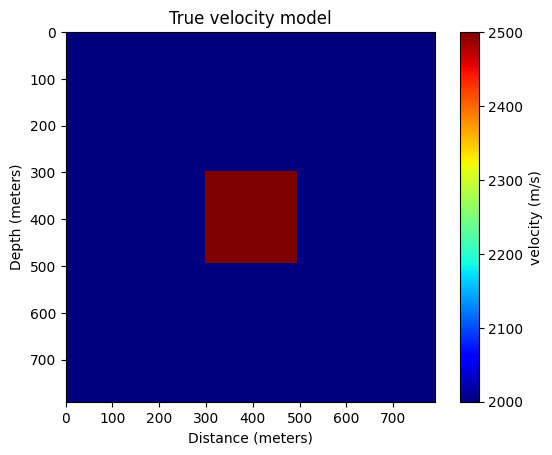

In [ ]:
plt.imshow(c_true,cmap='jet',extent=model_extent)
plt.title("True velocity model")
plt.xlabel("Distance (meters)")
plt.ylabel("Depth (meters)")
plt.colorbar(label="velocity (m/s)")
plt.show()

In [ ]:
# ==========================================================
# 2. TRUE MODEL (Circular Anomaly)
# ==========================================================

# import numpy as np

# c_true = 2000 * np.ones((nz, nx))

# # Circle parameters
# cx, cz = 40, 40      # center (x, z)
# r = 5             # radius

# # Create coordinate grid
# x = np.arange(nx)
# z = np.arange(nz)
# X, Z = np.meshgrid(x, z)

# # Circular mask
# mask = (X - cx)**2 + (Z - cz)**2 <= r**2

# # Assign anomaly
# c_true[mask] = 2500

# c_init = 2000 * np.ones_like(c_true)
# c = c_init.copy()
# m_true = 1/c_true**2
# m = 1/c_init**2


In [ ]:
# ==========================================================
# FREQUENCIES
# ==========================================================
frequencies = [
    3,4,
    5,6,
    7,15
]

# T_max_display = 2
# df = 1 / T_max_display   # 0.5 Hz

# frequencies = np.arange(df, 40, df)
# # frequencies = np.arange(2, 32, 1)
#f0 = 15.0



In [ ]:


# ==========================================================
# OBSERVED DATA
# Generate d_obs using the TRUE model
# ==========================================================


#projetion operator

P = sp.lil_matrix((nrec,n))
for i,r in enumerate(rec_idx):
    P[i,r]=1
P = P.tocsr()

d_obs = {}

for f in frequencies:
    omega = 2*np.pi*f
    #weight = (f**2 / f0**2) * np.exp(-f**2 / f0**2)
    d_obs[f] = []

    A =Forward_modelling.helmholtz5(m_true,omega,dx,dz,npml,vmax)
    LU = spla.splu(A.tocsc())

    for s in src_x:
        q = np.zeros(n,dtype=complex)
        q[idx(src_z,s)] = 1.0
        u = LU.solve(q)
        d_obs[f].append(P@u)   #*weight

In [ ]:
### Damping/ Regulariziation
#beta0= 1e-4 * omega**4
beta0=0.5


Effective eigenvalue scale: 123676308131901.81


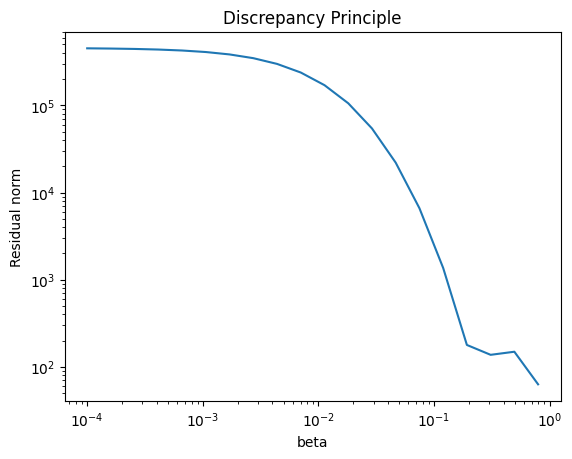

Selected beta (DP): 0.7943282347242815
Effective eigenvalue scale: 123676308131901.81


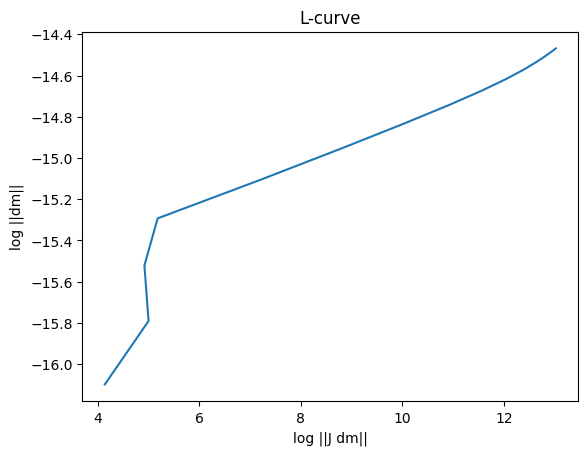

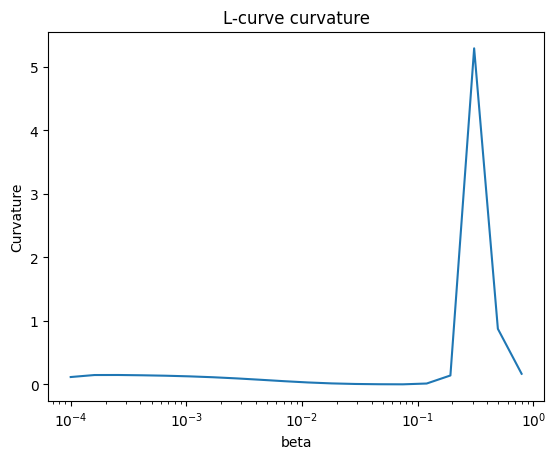

Selected beta (Jackson): 0.30865526123848624


In [ ]:
import matplotlib.pyplot as plt

beta_values = np.logspace(-4, -.1, 20)
#noise_level = 0.01 * np.linalg.norm(total_gradient)
noise_level=20

# ----- Discrepancy -----
beta_dp, residuals = discrepancy_principle(
    m, beta_values, f,
    d_obs, P, rec_idx,
    src_x, src_z,
    nx, nz, n, idx,
    dx, dz, npml, vmax,
    noise_level=noise_level,
    cg_maxiter=20
)


plt.loglog( beta_values,residuals)
#plt.axhline(1e-3, linestyle='--')

plt.xlabel("beta")
plt.ylabel("Residual norm")
plt.title("Discrepancy Principle")
plt.show()

print("Selected beta (DP):", beta_dp)


# ----- Jackson -----
beta_j, phi, psi, curvature = jackson_principle(
    m, beta_values, f,
    d_obs, P, rec_idx,
    src_x, src_z,
    nx, nz, n, idx,
    dx, dz, npml, vmax,
    cg_maxiter=20
)

plt.figure()
plt.plot(phi, psi)
plt.xlabel("log ||J dm||")
plt.ylabel("log ||dm||")
plt.title("L-curve")
plt.show()

plt.figure()
plt.semilogx(beta_values, curvature)
plt.xlabel("beta")
plt.ylabel("Curvature")
plt.title("L-curve curvature")
plt.show()

print("Selected beta (Jackson):", beta_j)

In [ ]:
# Example: use first frequency
f = frequencies[5]

g_field, misfit = compute_gradient_field(
    m, f, d_obs,
    P, rec_idx,
    src_x, src_z,
    nx, nz, n, idx,
    dx, dz, npml, vmax
)



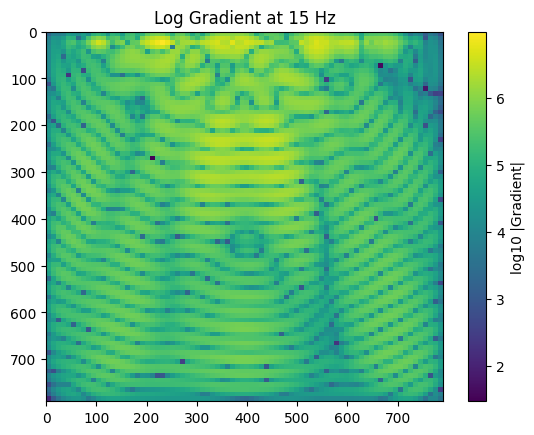

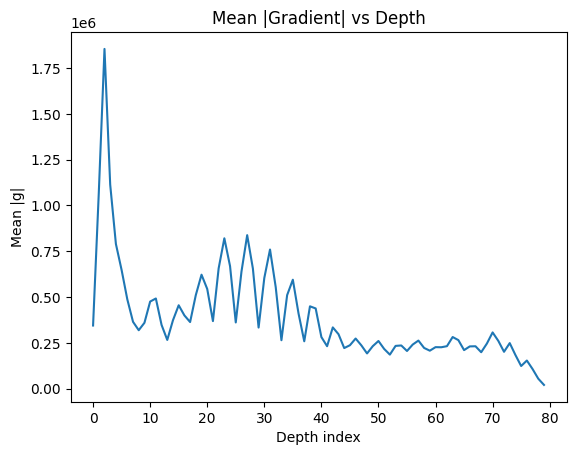

In [ ]:

plt.figure()
plt.imshow(np.log10(np.abs(g_field) + 1e-12),
           origin='upper', aspect='auto',extent=model_extent)
plt.colorbar(label='log10 |Gradient|')
plt.title(f'Log Gradient at {f} Hz')
plt.show()

depth_profile = np.mean(np.abs(g_field), axis=1)

plt.figure()
plt.plot(depth_profile)
plt.title("Mean |Gradient| vs Depth")
plt.xlabel("Depth index")
plt.ylabel("Mean |g|")
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

f = frequencies[5]

u_list, lam_list, prod_list = compute_forward_adjoint_fields(
    m, f, d_obs,
    P, rec_idx,
    src_x, src_z,
    nx, nz, n, idx,
    dx, dz, npml, vmax
)

# Choose one source to visualize
isrc =0

u = u_list[isrc]
lam = lam_list[isrc]
prod = prod_list[isrc]

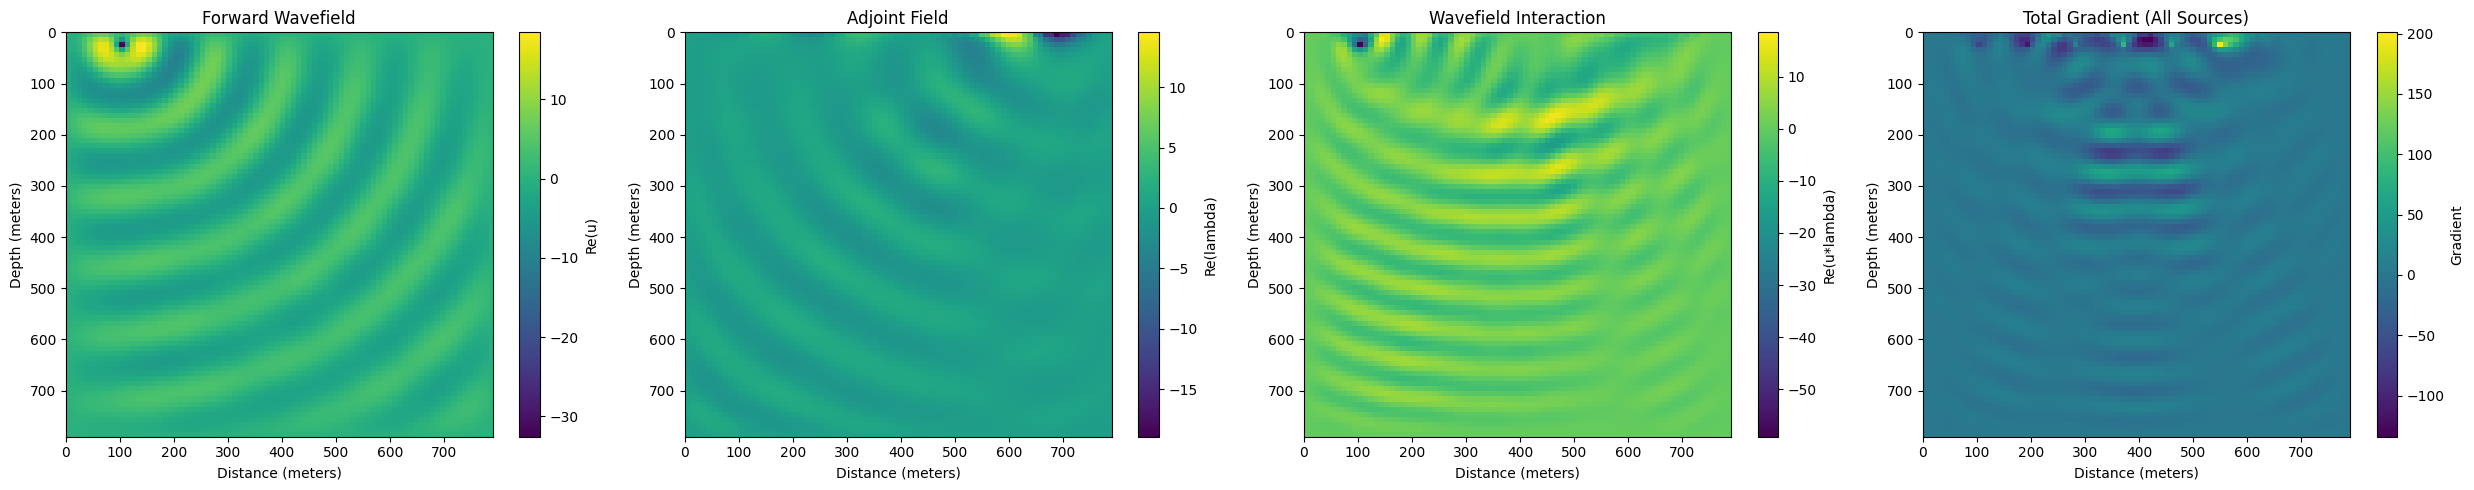

In [ ]:
plt.figure(figsize=(25,5))

# 1Forward field
plt.subplot(1,4,1)
plt.imshow(np.real(u),
           extent=model_extent,
           aspect='auto',
           origin='upper')
plt.colorbar(label='Re(u)')
plt.title('Forward Wavefield')
plt.xlabel("Distance (meters)")
plt.ylabel("Depth (meters)")

#  Adjoint field
plt.subplot(1,4,2)
plt.imshow(np.real(lam),
           extent=model_extent,
           aspect='auto',
           origin='upper')
plt.colorbar(label='Re(lambda)')
plt.title('Adjoint Field')
plt.xlabel("Distance (meters)")
plt.ylabel("Depth (meters)")


#  Interaction term
plt.subplot(1,4,3)
plt.imshow(prod,
           extent=model_extent,
           aspect='auto',
           origin='upper')
plt.colorbar(label='Re(u*lambda)')
plt.title('Wavefield Interaction')
plt.xlabel("Distance (meters)")
plt.ylabel("Depth (meters)")

# Total gradient
plt.subplot(1,4,4)
total_gradient = np.sum(prod_list, axis=0)
plt.imshow(total_gradient,
           extent=model_extent,
           aspect='auto',
           origin='upper')
plt.colorbar(label='Gradient')
plt.title('Total Gradient (All Sources)')
plt.xlabel("Distance (meters)")
plt.ylabel("Depth (meters)")

plt.tight_layout()
plt.show()

In [ ]:
m_gd,misfits_gd=Gradient(c_init, frequencies, d_obs,
                         P, rec_idx,
                        src_x, src_z,
                        nx, nz, n, idx,
                        dx,dz,npml,vmax,
                        n_iterations=12)


===== Frequency: 3 Hz =====
Iter: 1 Misfit: 13.528917722592528
Iter: 2 Misfit: 1.773061970619482
Iter: 3 Misfit: 0.9539615049134591
Iter: 4 Misfit: 0.7316625118611715
Iter: 5 Misfit: 0.4715076651321831
Iter: 6 Misfit: 0.34539717709440987
Iter: 7 Misfit: 0.2599239584637945
Iter: 8 Misfit: 0.23948126298823025
Iter: 9 Misfit: 0.1563901379307694
Iter: 10 Misfit: 0.13476772395021763
Iter: 11 Misfit: 0.11240774209423865
Iter: 12 Misfit: 0.10835225830585794

===== Frequency: 4 Hz =====
Iter: 1 Misfit: 28.36341044752357
Iter: 2 Misfit: 13.40540033879726
Iter: 3 Misfit: 9.26542897880338
Iter: 4 Misfit: 7.518883554015569
Iter: 5 Misfit: 6.920216877297111
Iter: 6 Misfit: 4.751882763435626
Iter: 7 Misfit: 2.9947828929025815
Iter: 8 Misfit: 2.6335279307179493
Iter: 9 Misfit: 2.374784577819743
Iter: 10 Misfit: 1.8715520013832738
Iter: 11 Misfit: 1.328005560581018
Iter: 12 Misfit: 1.1039040001713658

===== Frequency: 5 Hz =====
Iter: 1 Misfit: 3.186790172321372
Iter: 2 Misfit: 3.0154871756095214
Ite

Text(0, 0.5, 'Depth (meters)')

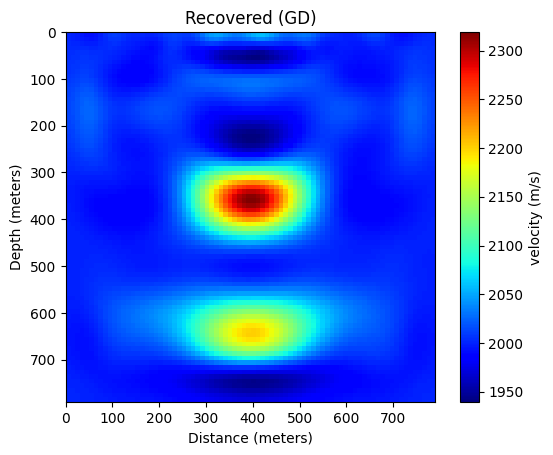

In [ ]:
plt.title("Recovered (GD)")
plt.imshow(1/np.sqrt(m_gd),cmap='jet',extent=model_extent)
plt.colorbar(label="velocity (m/s)")
plt.xlabel("Distance (meters)")
plt.ylabel("Depth (meters)")


In [ ]:
m_gn, misfits_gn=Gauss_newton(c_init,frequencies, d_obs,
                         P, rec_idx,
                        src_x, src_z,
                        nx, nz, n, idx,
                        dx,dz,npml,vmax,
                        beta0,
                        n_iterations=12,
                        cg_maxiter=20)


===== Frequency: 3 Hz =====
Iteration: 1 Misfit: 13.528917722592528 beta: 41.57852934624708
Iteration: 2 Misfit: 0.1350695953195438 beta: 20.78926467312354
Iteration: 3 Misfit: 0.003447791377528665 beta: 10.39463233656177
Iteration: 4 Misfit: 0.001942014614760664 beta: 5.197316168280885
Iteration: 5 Misfit: 0.0015894637663399856 beta: 2.5986580841404425
Iteration: 6 Misfit: 0.0014473400871960187 beta: 1.2993290420702213
Iteration: 7 Misfit: 0.0013346805955566012 beta: 0.6496645210351106
Iteration: 8 Misfit: 0.0012437796132391374 beta: 0.3248322605175553
Iteration: 9 Misfit: 0.0011666541496530834 beta: 0.16241613025877766
Iteration: 10 Misfit: 0.0011082866562281135 beta: 0.08120806512938883
Iteration: 11 Misfit: 0.0010557653470208005 beta: 0.040604032564694414
Iteration: 12 Misfit: 0.001000493575884109 beta: 0.020302016282347207

===== Frequency: 4 Hz =====
Iteration: 1 Misfit: 22.753477170396415 beta: 23.387922757263983
Iteration: 2 Misfit: 1.0457354045211444 beta: 11.693961378631991


Text(0, 0.5, 'Depth (meters)')

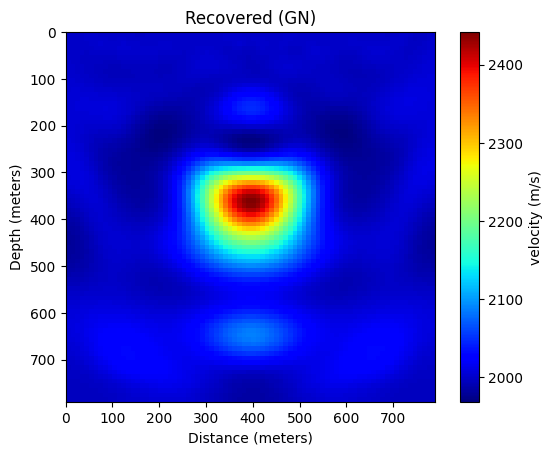

In [ ]:
plt.title("Recovered (GN)")
plt.imshow(1/np.sqrt(m_gn),cmap='jet',extent=model_extent)
plt.colorbar(label="velocity (m/s)")
plt.xlabel("Distance (meters)")
plt.ylabel("Depth (meters)")

In [ ]:
m_fn, misfits_fn=Full_newton(c_init, frequencies, d_obs,
                           P, rec_idx,
                           src_x, src_z,
                           nx, nz, n, idx,
                           dx,dz,npml,vmax,
                           beta0,
                           n_iterations=12,
                           minres_maxiter=20)


===== Frequency: 3 Hz =====
Iter: 1 Misfit: 13.528917722592528 beta: 374.2067641162237
Iter: 2 Misfit: 0.3082702924279441 beta: 187.10338205811186
Iter: 3 Misfit: 0.10208150647175296 beta: 93.55169102905593
Iter: 4 Misfit: 0.050603768414378844 beta: 46.775845514527965
Iter: 5 Misfit: 0.03330469683951191 beta: 23.387922757263983
Iter: 6 Misfit: 0.024319294695452246 beta: 11.693961378631991
Iter: 7 Misfit: 0.018906304954985312 beta: 5.846980689315996
Iter: 8 Misfit: 0.0153219481597596 beta: 2.923490344657998
Iter: 9 Misfit: 0.012804684673180574 beta: 1.461745172328999
Iter: 10 Misfit: 0.010964422432525187 beta: 0.7308725861644995
Iter: 11 Misfit: 0.009571995487266175 beta: 0.36543629308224973
Iter: 12 Misfit: 0.008484300856073195 beta: 0.18271814654112487

===== Frequency: 4 Hz =====
Iter: 1 Misfit: 29.370269092871503 beta: 374.2067641162237
Iter: 2 Misfit: 1.9784269072607317 beta: 187.10338205811186
Iter: 3 Misfit: 0.2665813094413302 beta: 93.55169102905593
Iter: 4 Misfit: 0.1518248279

Text(0, 0.5, 'Depth (meters)')

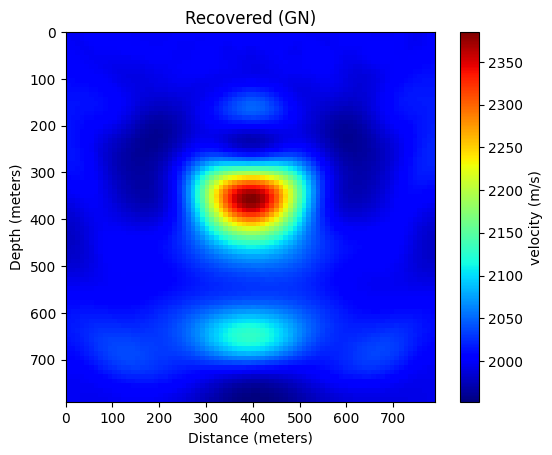

In [ ]:
plt.title("Recovered (GN)")
plt.imshow(1/np.sqrt(m_fn),cmap='jet',extent=model_extent)
plt.colorbar(label="velocity (m/s)")
plt.xlabel("Distance (meters)")
plt.ylabel("Depth (meters)")

In [ ]:
# choose two model parameters
i1, j1 = 6, 15
i2, j2 = 5, 2

p1 = idx(i1, j1)
p2 = idx(i2, j2)

def compute_misfit(m_test):
    total = 0.0

    for f in frequencies:
        omega = 2*np.pi*f
        # A expects a 2D array, which is correct: m_test.reshape(nz,nx)
        A = Forward_modelling.helmholtz5(m_test.reshape(nz,nx),
                                         omega,dx,dz,npml,vmax)
        LU = spla.splu(A.tocsc())

        for isrc, s in enumerate(src_x):
            q = np.zeros(n, dtype=complex)
            q[idx(src_z,s)] = 1.0
            u = LU.solve(q)
            d_pred = P@u

            residual = d_pred - d_obs[f][isrc]
            total += np.linalg.norm(residual)**2

    return 0.5 * total
# get final model
m_opt = m_gn # Corrected: m_gn is already slowness-squared
m_vec = m_opt.flatten()

# perturbation range
dp = np.linspace(-20e-8, 20e-8, 20)

J = np.zeros((len(dp), len(dp)))

for i,a in enumerate(dp):
    for j,b in enumerate(dp):
        m_test = m_vec.copy()
        m_test[p1] += a
        m_test[p2] += b

        J[i,j] = compute_misfit(m_test)

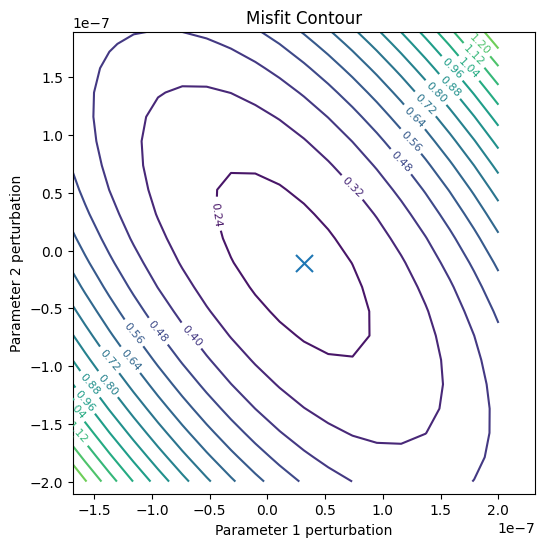

In [ ]:
import matplotlib.pyplot as plt

X, Y = np.meshgrid(dp, dp)

plt.figure(figsize=(7,6))
cs = plt.contour(X, Y, J, 20)
plt.clabel(cs, inline=True, fontsize=8)

# mark center (minimum)
min_idx = np.unravel_index(np.argmin(J), J.shape)
min_x_val = X[min_idx] # Actual x-perturbation value at minimum
min_y_val = Y[min_idx] # Actual y-perturbation value at minimum

# Calculate the span of the current dp range
plot_span = np.max(dp) - np.min(dp)

# Introduce an extend factor to widen the view and ensure the whole ellipse is visible
extend_factor = 1# Increased extend factor

# Set new xlim and ylim to center the minimum and extend the view
plt.xlim(min_x_val - (plot_span/2) * extend_factor, min_x_val + (plot_span/2) * extend_factor)
plt.ylim(min_y_val - (plot_span/2) * extend_factor, min_y_val + (plot_span/2) * extend_factor)

plt.scatter(min_x_val, min_y_val,
            marker='x', s=150)

plt.xlabel("Parameter 1 perturbation")
plt.ylabel("Parameter 2 perturbation")
plt.title("Misfit Contour")
plt.gca().set_aspect('equal')

plt.show()

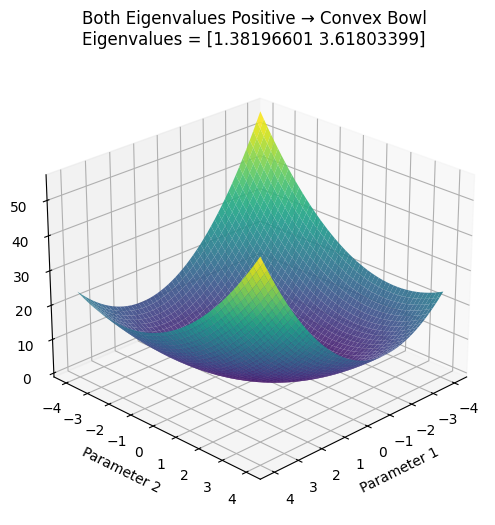

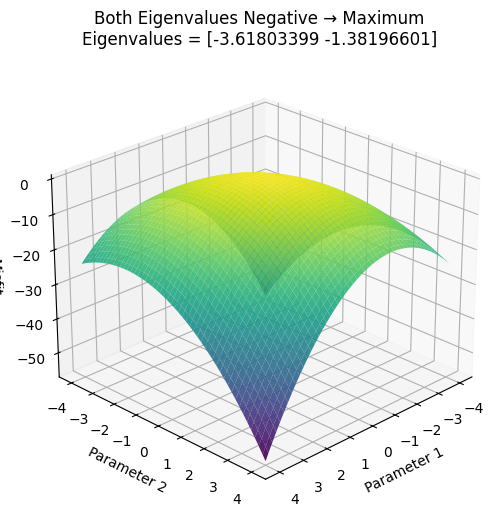

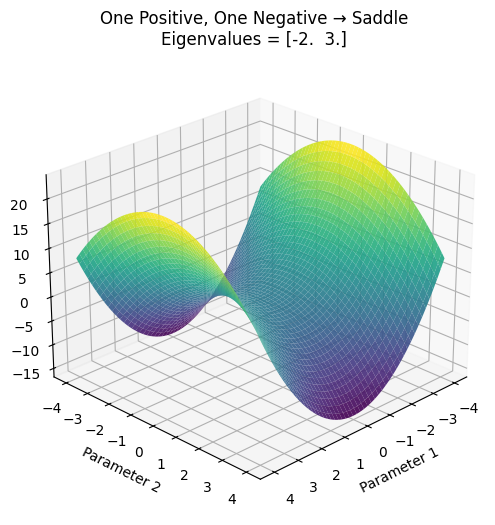

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ----------------------------------------------------------
# Parameter grid
# ----------------------------------------------------------
x = np.linspace(-4, 4, 200)
y = np.linspace(-4, 4, 200)
X, Y = np.meshgrid(x, y)

def plot_surface(H, title):

    # Quadratic form
    Z = 0.5*(H[0,0]*X**2 + 2*H[0,1]*X*Y + H[1,1]*Y**2)

    eigvals, _ = np.linalg.eigh(H)

    fig = plt.figure(figsize=(7,6))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot_surface(X, Y, Z, cmap='viridis',
                    edgecolor='none', alpha=0.9)

    ax.set_title(f"{title}\nEigenvalues = {eigvals}")
    ax.set_xlabel("Parameter 1")
    ax.set_ylabel("Parameter 2")
    ax.set_zlabel("Misfit")

    ax.view_init(elev=25, azim=45)
    plt.show()


# ==========================================================
# 1️⃣ Convex bowl (minimum)
# ==========================================================
H_positive = np.array([[3, 1],
                       [1, 2]])

plot_surface(H_positive,
             "Both Eigenvalues Positive → Convex Bowl")


# ==========================================================
# 2️⃣ Upside-down bowl (maximum)
# ==========================================================
H_negative = np.array([[-3, -1],
                       [-1, -2]])

plot_surface(H_negative,
             "Both Eigenvalues Negative → Maximum")


# ==========================================================
# 3️⃣ Saddle surface
# ==========================================================
H_saddle = np.array([[3, 0],
                     [0, -2]])

plot_surface(H_saddle,
             "One Positive, One Negative → Saddle")

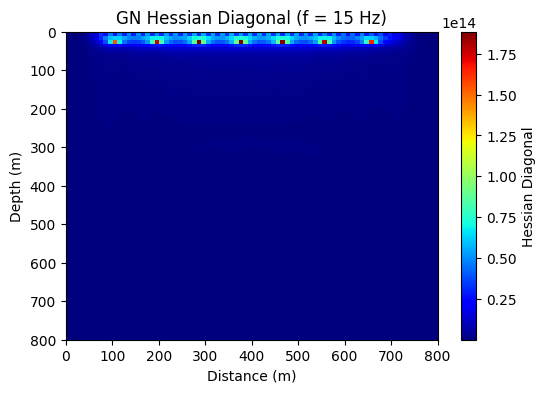

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Build Hessian
H_linop = Hessian(m_true, f,
                  d_obs,
                  P, rec_idx,
                  src_x, src_z,
                  nx, nz, n, idx,
                  dx, dz, npml, vmax,
                  beta0)

# Compute diagonal
diagH = np.zeros(n)

for i in range(n):
    e = np.zeros(n)
    e[i] = 1.0
    diagH[i] = (H_linop @ e)[i]

plt.figure(figsize=(6,4))
plt.imshow(diagH.reshape(nz, nx),
           cmap='jet',
           extent=[0, nx*dx, nz*dz, 0],
           aspect='auto')
plt.colorbar(label='Hessian Diagonal')
plt.title(f'GN Hessian Diagonal (f = {f} Hz)')
plt.xlabel('Distance (m)')
plt.ylabel('Depth (m)')
plt.show()

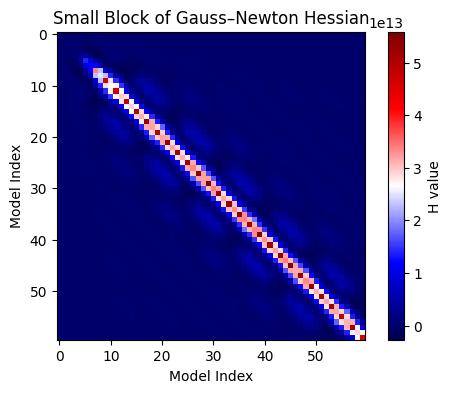

In [ ]:
k = 60  # small block size

H_small = np.zeros((k, k))

for i in range(k):
    e = np.zeros(n)
    e[i] = 1.0
    H_small[:, i] = (H_linop @ e)[:k]

plt.figure(figsize=(6,4))
plt.imshow(H_small, cmap='seismic')
plt.colorbar(label='H value')
plt.title('Small Block of Gauss–Newton Hessian')
plt.xlabel('Model Index')
plt.ylabel('Model Index')
plt.show()

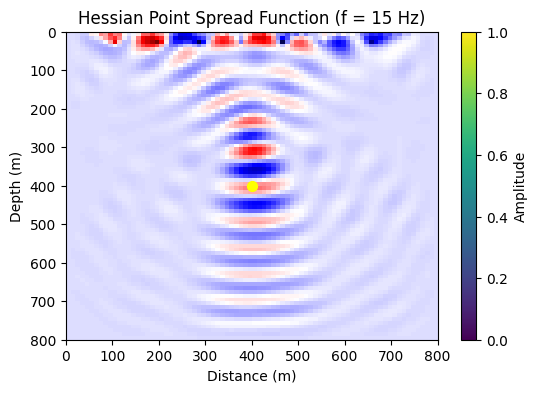

In [ ]:
# Choose point in model
iz = nz // 2
ix = nx // 2
center = iz * nx + ix

e = np.zeros(n)
e[center] = 1.0

psf = H_linop @ e

plt.figure(figsize=(6,4))
plt.imshow(psf.reshape(nz, nx),
           cmap='seismic',
           extent=[0, nx*dx, nz*dz, 0],
           aspect='auto')
plt.scatter(ix*dx, iz*dz, c='yellow', s=50)
plt.colorbar(label='Amplitude')
plt.title(f'Hessian Point Spread Function (f = {f} Hz)')
plt.xlabel('Distance (m)')
plt.ylabel('Depth (m)')
plt.show()

In [ ]:
eigvals, eigvecs = np.linalg.eigh(diagH.reshape(nz, nx) )

print("Smallest eigenvalues:")
print(eigvals[:10])

print("Largest eigenvalues:")
print(eigvals[-10:])

Smallest eigenvalues:
[-1.11378462e+12 -7.58246091e+11 -4.99351853e+11 -2.41641678e+11
 -3.95327148e+10 -2.37077050e+10 -2.24941755e+10 -2.02613225e+10
 -1.07305446e+10 -8.67580192e+09]
Largest eigenvalues:
[1.45072357e+11 2.00983463e+11 2.63706076e+11 2.93482242e+11
 4.56653411e+11 6.87002317e+11 8.79310150e+11 1.32243088e+12
 1.58844972e+12 9.30525109e+12]


In [ ]:
eigvals, eigvecs = spla.eigsh(
    H_linop,
    k=5,
    which='LM'   # Largest magnitude
)

print("Top 5 eigenvalues:")
print(eigvals)

Top 5 eigenvalues:
[3.46087189e+14 3.48195977e+14 3.87562605e+14 4.43801384e+14
 5.34409756e+14]


In [ ]:
eigvals_small, eigvecs= spla.eigsh(
    H_linop,
    k=2,
    which='SM',
    maxiter=5   # Smallest magnitude
)

print("Smallest 5 eigenvalues:")
print(eigvals_small)

ArpackNoConvergence: ARPACK error -1: No convergence (6 iterations, 0/2 eigenvectors converged)

In [ ]:
def smallest_eigenvalue_estimate(H_linop, n, cg_maxiter=30, iters=10):

    import numpy as np
    import scipy.sparse.linalg as spla

    # random initial vector
    x = np.random.randn(n)
    x /= np.linalg.norm(x)

    for _ in range(iters):

        # Solve H y = x  (approx inverse multiplication)
        y, _ = spla.cg(H_linop, x, maxiter=cg_maxiter)

        # normalize
        x = y / np.linalg.norm(y)

    # Rayleigh quotient
    lambda_min = x @ (H_linop @ x)

    return lambda_min

In [ ]:
lambda_min = smallest_eigenvalue_estimate(H_linop, n)

print("Approx smallest eigenvalue:", lambda_min)

Approx smallest eigenvalue: 19212193.990740016


In [ ]:
Hg = H_linop @ total_gradient.flatten()
rq = (total_gradient.flatten() @ Hg) / (total_gradient.flatten() @ total_gradient.flatten())
print("Effective eigenvalue along gradient direction:", rq)

Effective eigenvalue along gradient direction: 75746403269033.89


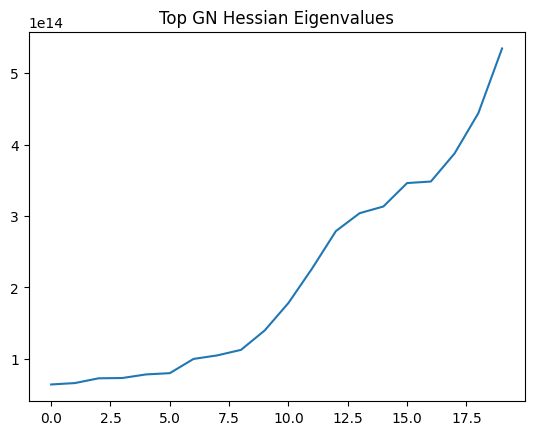

In [ ]:
eigvals = spla.eigsh( H_linop, k=20, which='LM', return_eigenvectors=False)

plt.plot(eigvals)
plt.title("Top GN Hessian Eigenvalues")
plt.show()

In [ ]:
print("Condition number:", eigvals[-1]/lambda_min)

Condition number: 27816175.315665755


In [ ]:
v1 = eigvecs[:, -1]   # largest eigenvalue
v2 = eigvecs[:, -2]   # second largest

In [ ]:
a = np.linspace(-1e-3, 1e-3, 200)
b = np.linspace(-1e-3, 1e-3, 200)

Agrid, Bgrid = np.meshgrid(a, b)

lambda1 = eigvals[-1]
lambda2 = eigvals[-2]

Z = 0.5*(lambda1*Agrid**2 + lambda2*Bgrid**2)

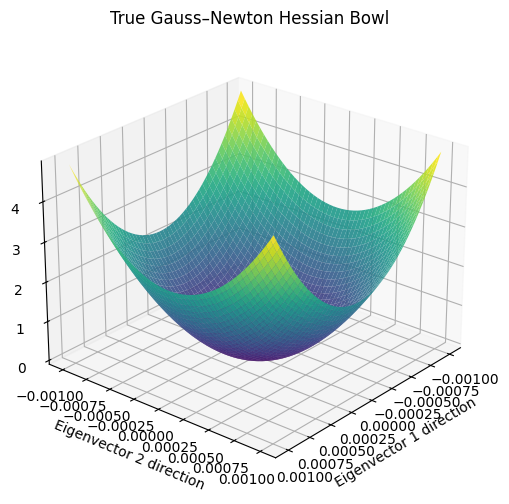

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(Agrid, Bgrid, Z,
                cmap='viridis',
                edgecolor='none',
                alpha=0.9)

ax.set_title("True Gauss–Newton Hessian Bowl")
ax.set_xlabel("Eigenvector 1 direction")
ax.set_ylabel("Eigenvector 2 direction")
ax.set_zlabel("Misfit")

ax.view_init(elev=25, azim=40)
plt.show()

In [1]:
plt.figure(figsize=(7, 7))
f_plot = frequencies[4]
omega = 2*np.pi*f_plot
s_idx = 3
s_val = src_x[s_idx]

A =Forward_modelling.helmholtz5(m_true,omega,dx,dz,npml,vmax)
LU = spla.splu(A.tocsc())

q = np.zeros(n, dtype=complex)
q[idx(src_z, s_val)] = 1.0
u = LU.solve(q)

U_2d = u.reshape((nz, nx))
# extent = [left, right, bottom, top]


plt.imshow(np.real(U_2d), cmap='RdBu', extent=model_extent)

plt.scatter(src_x_phys[s_idx],  src_z_phys, c='red', marker='*', s=100, label=f'Source: {s_idx }')
plt.scatter(rec_x_phys, [rec_z_phys]*len(rec_x), c='black', marker='v', s=10, label=f' NO of Receivers: {nrec}')
plt.legend()
plt.title(f"Pressure Wavefield at Frequency {f_plot} Hz")
plt.xlabel("Distance (meters)")
plt.ylabel("Depth (meters)")
plt.colorbar(label="Pressure")
plt.tight_layout
plt.show()


NameError: name 'plt' is not defined

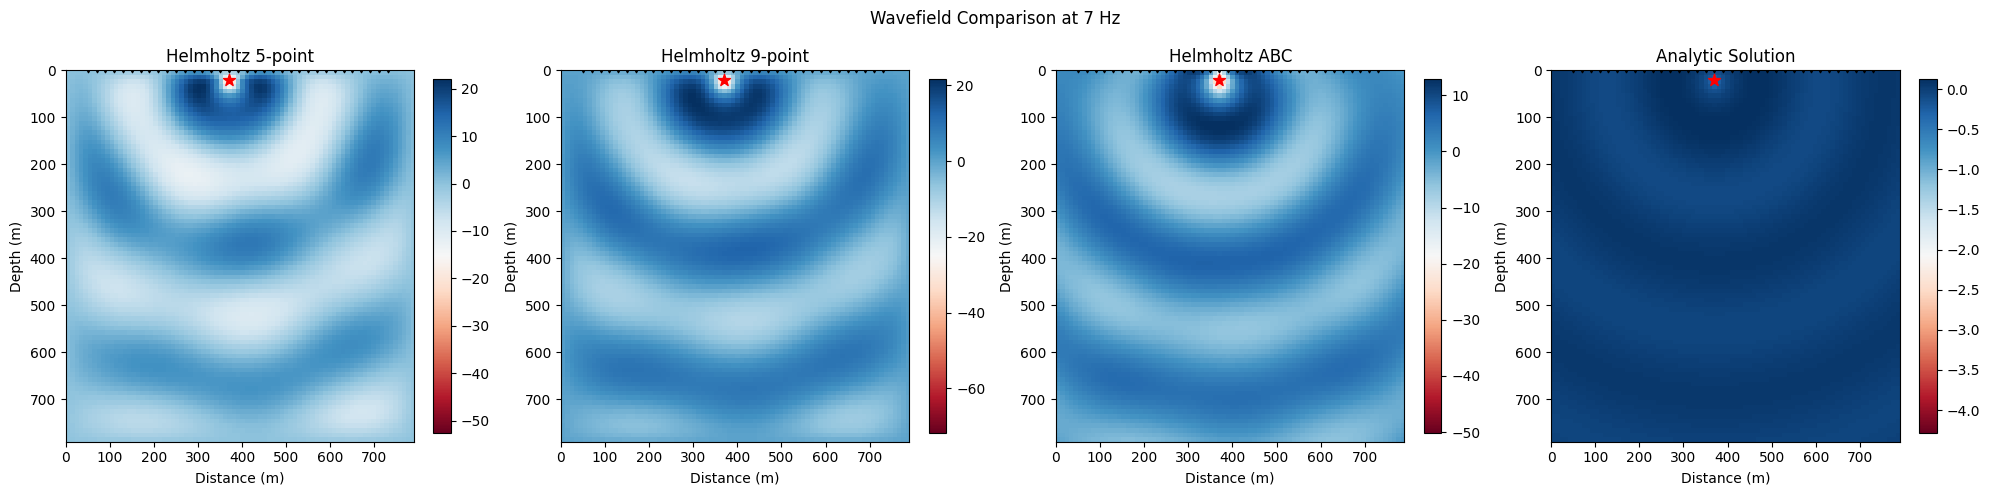

In [ ]:

# ----------------------------------------------------------
# Select frequency and source
# ----------------------------------------------------------
f_plot = frequencies[4]
omega = 2 * np.pi * f_plot

s_idx = 3
s_val = src_x[s_idx]

# ----------------------------------------------------------
# Source vector
# ----------------------------------------------------------
q = np.zeros(n, dtype=complex)
q[idx(src_z, s_val)] = 1.0

# ----------------------------------------------------------
# Build matrices
# ----------------------------------------------------------
A5  = helmholtz5(m_true, omega, dx, dz, npml, vmax)
A9  = helmholtz9(m_true, omega, dx, dz, npml, vmax)
Aabc = helmholtzabc(m_true, omega, dx, dz, npml, vmax)

# Factorizations
LU5  = spla.splu(A5.tocsc())
LU9  = spla.splu(A9.tocsc())
LUabc = spla.splu(Aabc.tocsc())

# Solve
u5   = LU5.solve(q).reshape(nz, nx)
u9   = LU9.solve(q).reshape(nz, nx)
uabc = LUabc.solve(q).reshape(nz, nx)

# Analytic solution (no matrix solve)
velocity = 2000
sx = src_x[len(src_x)//2]
sz = src_z
u_analytic = analytic_2d_helmholtz(
    nx, nz, dx, dz,
    omega, velocity,
    sx, sz
).reshape(nz, nx)

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------
fig, axs = plt.subplots(1, 4, figsize=(20, 5))

titles = [
    "Helmholtz 5-point",
    "Helmholtz 9-point",
    "Helmholtz ABC",
    "Analytic Solution"
]

wavefields = [
    np.real(u5),
    np.real(u9),
    np.real(uabc),
    np.real(u_analytic)
]

for ax, wf, title in zip(axs, wavefields, titles):

    im = ax.imshow(
        wf,
        cmap='RdBu',
        extent=model_extent,
        aspect='auto'
    )

    ax.scatter(
        src_x_phys[s_idx],
        src_z_phys,
        c='red',
        marker='*',
        s=80
    )

    ax.scatter(
        rec_x_phys,
        [rec_z_phys] * len(rec_x_phys),
        c='black',
        marker='v',
        s=10
    )

    ax.set_title(title)
    ax.set_xlabel("Distance (m)")
    ax.set_ylabel("Depth (m)")

    fig.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle(f"Wavefield Comparison at {f_plot} Hz")
plt.tight_layout()
plt.show()

In [ ]:
l2_error_5_vs_analytic = np.linalg.norm(u5- u_analytic) / np.linalg.norm(u_analytic)
l2_error_9_vs_analytic = np.linalg.norm(u9 - u_analytic) / np.linalg.norm(u_analytic)
l2_error_abc_vs_analytic = np.linalg.norm(uabc- u_analytic) / np.linalg.norm(u_analytic)
print(f"Relative L2 Error (ABC vs Analytic): {l2_error_abc_vs_analytic:.4e}")
print(f"Relative L2 Error (5-point vs Analytic): {l2_error_5_vs_analytic:.4e}")
print(f"Relative L2 Error (9-point vs Analytic): {l2_error_9_vs_analytic:.4e}")

Relative L2 Error (ABC vs Analytic): 7.3985e+01
Relative L2 Error (5-point vs Analytic): 1.0407e+02
Relative L2 Error (9-point vs Analytic): 1.1425e+02


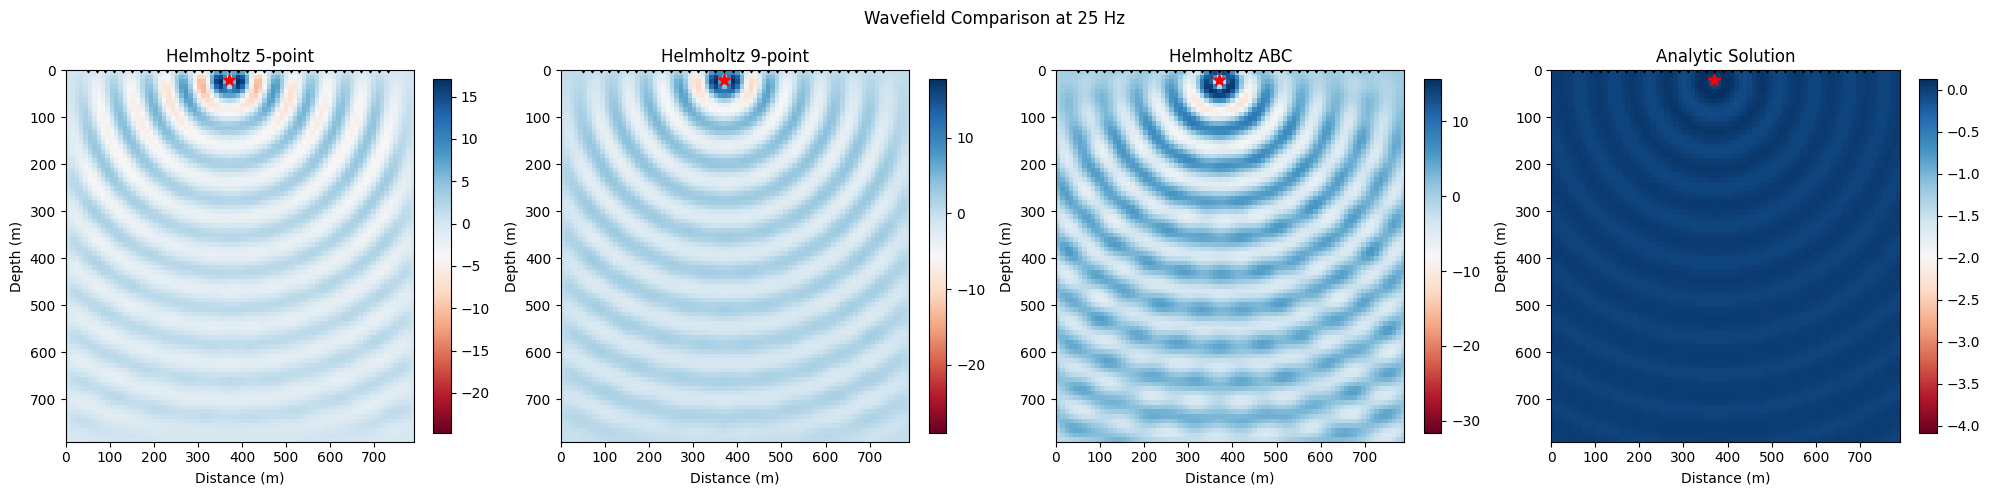

In [ ]:

# ----------------------------------------------------------
# Select frequency and source
# ----------------------------------------------------------
f_plot = frequencies[5]
omega = 2 * np.pi * f_plot

s_idx = 3
s_val = src_x[s_idx]

# ----------------------------------------------------------
# Source vector
# ----------------------------------------------------------
q = np.zeros(n, dtype=complex)
q[idx(src_z, s_val)] = 1.0

# ----------------------------------------------------------
# Build matrices
# ----------------------------------------------------------
A5  = helmholtz5(m_true, omega, dx, dz, npml, vmax)
A9  = helmholtz9(m_true, omega, dx, dz, npml, vmax)
Aabc = helmholtzabc(m_true, omega, dx, dz, npml, vmax)

# Factorizations
LU5  = spla.splu(A5.tocsc())
LU9  = spla.splu(A9.tocsc())
LUabc = spla.splu(Aabc.tocsc())

# Solve
u5   = LU5.solve(q).reshape(nz, nx)
u9   = LU9.solve(q).reshape(nz, nx)
uabc = LUabc.solve(q).reshape(nz, nx)

# Analytic solution (no matrix solve)
velocity = 2000
sx = src_x[len(src_x)//2]
sz = src_z
u_analytic = analytic_2d_helmholtz(
    nx, nz, dx, dz,
    omega, velocity,
    sx, sz
).reshape(nz, nx)

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------
fig, axs = plt.subplots(1, 4, figsize=(20, 5))

titles = [
    "Helmholtz 5-point",
    "Helmholtz 9-point",
    "Helmholtz ABC",
    "Analytic Solution"
]

wavefields = [
    np.real(u5),
    np.real(u9),
    np.real(uabc),
    np.real(u_analytic)
]

for ax, wf, title in zip(axs, wavefields, titles):

    im = ax.imshow(
        wf,
        cmap='RdBu',
        extent=model_extent,
        aspect='auto'
    )

    ax.scatter(
        src_x_phys[s_idx],
        src_z_phys,
        c='red',
        marker='*',
        s=80
    )

    ax.scatter(
        rec_x_phys,
        [rec_z_phys] * len(rec_x_phys),
        c='black',
        marker='v',
        s=10
    )

    ax.set_title(title)
    ax.set_xlabel("Distance (m)")
    ax.set_ylabel("Depth (m)")

    fig.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle(f"Wavefield Comparison at {f_plot} Hz")
plt.tight_layout()
plt.show()

In [ ]:
l2_error_5_vs_analytic = np.linalg.norm(u5- u_analytic) / np.linalg.norm(u_analytic)
l2_error_9_vs_analytic = np.linalg.norm(u9 - u_analytic) / np.linalg.norm(u_analytic)
l2_error_abc_vs_analytic = np.linalg.norm(uabc- u_analytic) / np.linalg.norm(u_analytic)
print(f"Relative L2 Error (ABC vs Analytic): {l2_error_abc_vs_analytic:.4e}")
print(f"Relative L2 Error (5-point vs Analytic): {l2_error_5_vs_analytic:.4e}")
print(f"Relative L2 Error (9-point vs Analytic): {l2_error_9_vs_analytic:.4e}")


Relative L2 Error (ABC vs Analytic): 7.0416e+01
Relative L2 Error (5-point vs Analytic): 4.8930e+01
Relative L2 Error (9-point vs Analytic): 4.6944e+01


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# 1. Pre-calculate all wavefields (to keep animation smooth)
u_list = []
for s in src_x:
    q = np.zeros(n, dtype=complex)
    q[idx(src_z, s)] = 1.0
    u_list.append(LU.solve(q))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), gridspec_kw={'height_ratios': [2, 1]})

# Setup 2D Plot
im = ax1.imshow(np.zeros((nz, nx)), cmap='RdBu', extent=[0, nx*dx, nz*dz, 0], vmin=-50, vmax=15)
src_marker = ax1.scatter([], [], c='red', marker='*', s=200, label='Active Source')
ax1.scatter(rec_x*dx, [rec_z*dz]*nrec, c='black', marker='v', s=10, label='Receivers')
ax1.set_title("Pressure Wavefield Propagation")
ax1.legend()

# Setup 1D "Live Recorder" Plot
line, = ax2.plot(rec_x*dx, np.zeros(nrec), color='blue', lw=1.5)
ax2.set_ylim(-1, 1)
ax2.set_xlim(rec_x[0]*dx, rec_x[-1]*dx)
ax2.set_title("Live Receiver Recording (Instantaneous Pressure)")
ax2.set_xlabel("Distance X (m)")

# 3. Animation Function
frames_per_source = 40  # Number of frames to show one full wave cycle
total_frames = nsrc * frames_per_source

def update(frame):
    # Determine which source is "blasting"
    s_idx = (frame // frames_per_source) % nsrc
    # Calculate phase rotation (0 to 2pi)
    phase = 2 * np.pi * (frame % frames_per_source) / frames_per_source

    # Rotate the complex field in time
    u_complex = u_list[s_idx]
    u_real_2d = np.real(u_complex * np.exp(-1j * phase)).reshape((nz, nx))

    # Update 2D Wavefield
    im.set_data(u_real_2d)
    src_marker.set_offsets([[src_x[s_idx]*dx, src_z*dz]])

    # Update 1D Recording (Extract values at receiver indices)
    # This is equivalent to P @ (u * exp(-i*phase))
    rec_values = np.real((P @ u_complex) * np.exp(-1j * phase))
    line.set_ydata(rec_values)

    return im, src_marker, line

# 4. Run the Animation
ani = FuncAnimation(fig, update, frames=total_frames, interval=50, blit=True)
plt.close(fig)
display(HTML(ani.to_jshtml()))



KeyboardInterrupt: 

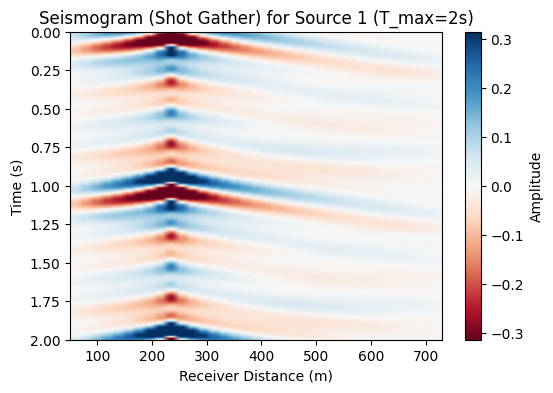

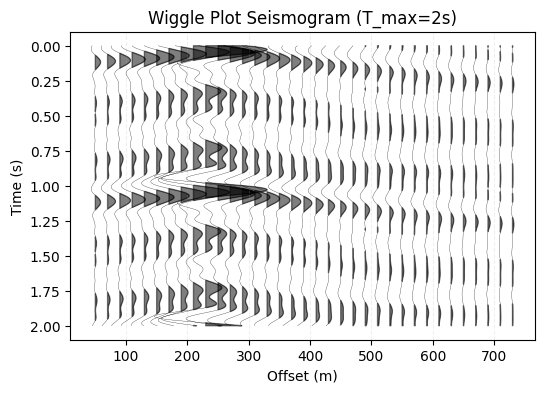

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup parameters
shot_idx = 1
n_rec = len(rec_x)

# Define the desired total time window for the seismogram (e.g., based on max travel time)

T_max_display = 2
n_time_samples = 1000

# Recalculate dt_effective based on the chosen n_time_samples and T_max_display
dt_effective = T_max_display / n_time_samples
df_effective = 1 / T_max_display

# 2. Prepare the frequency domain input for irfft

padded_f_domain_data_obs = np.zeros((n_time_samples // 2 + 1, n_rec), dtype=complex)
frequencies_sorted = np.sort(frequencies)

# Create a mapping from actual physical frequency values to indices in the padded array
for freq_idx, f_val in enumerate(frequencies_sorted):

    k_index = int(round(f_val / df_effective))

    if k_index < padded_f_domain_data_obs.shape[0]:
        padded_f_domain_data_obs[k_index, :] = d_obs[f_val][shot_idx]    #######
    else:
        print(f"Warning: Frequency {f_val} Hz is too high for the chosen T_max_display ({T_max_display} s) and n_time_samples ({n_time_samples}).\n         Max frequency index supported is {padded_f_domain_data_obs.shape[0]-1}*df_effective = {(padded_f_domain_data_obs.shape[0]-1)*df_effective} Hz.")



# 3. Perform IFFT
seismogram = np.fft.irfft(np.conj(padded_f_domain_data_obs), axis=0, n=n_time_samples)

# 4. Plotting the Seismogram
plt.figure(figsize=(6,4))

v_max = np.percentile(np.abs(seismogram), 98)
plt.imshow(seismogram, aspect='auto', cmap='RdBu',
           extent=[rec_x[0]*dx, rec_x[-1]*dx, T_max_display, 0],
           vmin=-v_max, vmax=v_max)

plt.title(f"Seismogram (Shot Gather) for Source {shot_idx} (T_max={T_max_display}s)")
plt.xlabel("Receiver Distance (m)")
plt.ylabel("Time (s)")
plt.colorbar(label="Amplitude")
plt.show()

# Update the wiggle plot as well
plt.figure(figsize=(6,4))
time_axis = np.linspace(0, T_max_display, seismogram.shape[0])

global_max_amplitude = -np.max(np.abs(seismogram))
display_scale_factor = (dx * 10) / global_max_amplitude


for i in range(0, n_rec, 1):
    trace = seismogram[:, i] * display_scale_factor
    plt.plot(rec_x[i]*dx + trace, time_axis, color='black', lw=.2)
    plt.fill_betweenx(time_axis, rec_x[i]*dx, rec_x[i]*dx + trace,
                     where=(trace > 0), color='black', alpha=.5)

plt.gca().invert_yaxis()
plt.title(f"Wiggle Plot Seismogram (T_max={T_max_display}s)")
plt.xlabel("Offset (m)")
plt.ylabel("Time (s)")
plt.grid(axis='x', linestyle='--', alpha=.2)
plt.show()


In [ ]:
# # ==========================================================
# # Recovered DATA
# # Generate d_obs using the TRUE model
# # ==========================================================


# #projetion operator

# P = sp.lil_matrix((nrec,n))
# for i,r in enumerate(rec_idx):
#     P[i,r]=1
# P = P.tocsr()

# d_recover = {}

# for f in frequencies:
#     omega = 2*np.pi*f
#     #weight = (f**2 / f0**2) * np.exp(-f**2 / f0**2)
#     d_recover[f] = []

#     A =Forward_modelling.helmholtz5(m_gn,omega,dx,dz,npml,vmax)
#     LU = spla.splu(A.tocsc())

#     for s in src_x:
#         q = np.zeros(n,dtype=complex)
#         q[idx(src_z,s)] = 1.0
#         u = LU.solve(q)
#         d_recover[f].append(P@u)   #*weight

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt

# # 1. Setup parameters
# shot_idx = 1
# n_rec = len(rec_x)

# # Define the desired total time window for the seismogram (e.g., based on max travel time)

# T_max_display = 2.0  # Set to match cell IdFwEakPANQF
# n_time_samples = 1000 # Set to match cell IdFwEakPANQF

# # Recalculate dt_effective based on the chosen n_time_samples and T_max_display
# dt_effective = T_max_display / n_time_samples
# df_effective = 1 / T_max_display

# # 2. Prepare the frequency domain input for irfft

# padded_f_domain_data_recover = np.zeros((n_time_samples // 2 + 1, n_rec), dtype=complex)
# frequencies_sorted = np.sort(frequencies)

# # Create a mapping from actual physical frequency values to indices in the padded array
# for freq_idx, f_val in enumerate(frequencies_sorted):

#     k_index = int(round(f_val / df_effective))

#     if k_index < padded_f_domain_data_recover.shape[0]:
#         padded_f_domain_data_recover[k_index, :] = d_recover[f_val][shot_idx]    #######
#     else:
#         print(f"Warning: Frequency {f_val} Hz is too high for the chosen T_max_display ({T_max_display} s) and n_time_samples ({n_time_samples}).\n         Max frequency index supported is {padded_f_domain_data_recover.shape[0]-1}*df_effective = {(padded_f_domain_data_recover.shape[0]-1)*df_effective} Hz.")

# # 3. Perform IFFT
# seismogram_r = np.fft.irfft(np.conj(padded_f_domain_data_recover), axis=0, n=n_time_samples)


# # Update the wiggle plot as well
# plt.figure(figsize=(6,4))
# time_axis = np.linspace(0, T_max_display, (seismogram_r).shape[0])

# global_max_amplitude = -np.max(np.abs(seismogram_r))
# display_scale_factor = (dx * 5) / global_max_amplitude


# for i in range(0, n_rec, 1):
#     trace = (seismogram_r)[:, i] * display_scale_factor
#     plt.plot(rec_x[i]*dx + trace, time_axis, color='black', lw=.2)
#     plt.fill_betweenx(time_axis, rec_x[i]*dx, rec_x[i]*dx + trace,
#                      where=(trace > 0), color='black', alpha=.5)

# plt.gca().invert_yaxis()
# plt.title(f"Recovered Wiggle Plot Seismogram (T_max={T_max_display}s)")
# plt.xlabel("Offset (m)")
# plt.ylabel("Time (s)")
# plt.grid(axis='x', linestyle='--', alpha=0.1)
# plt.show()

### Generate Recovered Data and Seismogram for Gradient Descent (GD)

In [ ]:
# ==========================================================
# Recovered DATA for GD model
# ==========================================================

d_recover_gd = {}

for f in frequencies:
    omega = 2*np.pi*f
    d_recover_gd[f] = []

    A = Forward_modelling.helmholtz5(m_gd,omega,dx,dz,npml,vmax)
    LU = spla.splu(A.tocsc())

    for s in src_x:
        q = np.zeros(n,dtype=complex)
        q[idx(src_z,s)] = 1.0
        u = LU.solve(q)
        d_recover_gd[f].append(P@u)

padded_f_domain_data_recover_gd = np.zeros((n_time_samples // 2 + 1, n_rec), dtype=complex)
for freq_idx, f_val in enumerate(frequencies_sorted):
    k_index = int(round(f_val / df_effective))
    if k_index < padded_f_domain_data_recover_gd.shape[0]:
        padded_f_domain_data_recover_gd[k_index, :] = d_recover_gd[f_val][shot_idx]
seismogram_gd = np.fft.irfft(np.conj(padded_f_domain_data_recover_gd), axis=0, n=n_time_samples)

GN

In [ ]:
# ==========================================================
# Recovered DATA for GD model
# ==========================================================

d_recover_gn = {}

for f in frequencies:
    omega = 2*np.pi*f
    d_recover_gn[f] = []

    A = Forward_modelling.helmholtz5(m_gn,omega,dx,dz,npml,vmax)
    LU = spla.splu(A.tocsc())

    for s in src_x:
        q = np.zeros(n,dtype=complex)
        q[idx(src_z,s)] = 1.0
        u = LU.solve(q)
        d_recover_gn[f].append(P@u)

padded_f_domain_data_recover_gn = np.zeros((n_time_samples // 2 + 1, n_rec), dtype=complex)
for freq_idx, f_val in enumerate(frequencies_sorted):
    k_index = int(round(f_val / df_effective))
    if k_index < padded_f_domain_data_recover_gn.shape[0]:
        padded_f_domain_data_recover_gn[k_index, :] = d_recover_gn[f_val][shot_idx]
seismogram_gn = np.fft.irfft(np.conj(padded_f_domain_data_recover_gn), axis=0, n=n_time_samples)

### Generate Recovered Data and Seismogram for Full Newton (FN)

In [ ]:
# ==========================================================
# Recovered DATA for FN model
# ==========================================================

d_recover_fn = {}

for f in frequencies:
    omega = 2*np.pi*f
    d_recover_fn[f] = []

    A = Forward_modelling.helmholtz5(m_fn,omega,dx,dz,npml,vmax)
    LU = spla.splu(A.tocsc())

    for s in src_x:
        q = np.zeros(n,dtype=complex)
        q[idx(src_z,s)] = 1.0
        u = LU.solve(q)
        d_recover_fn[f].append(P@u)

padded_f_domain_data_recover_fn = np.zeros((n_time_samples // 2 + 1, n_rec), dtype=complex)
for freq_idx, f_val in enumerate(frequencies_sorted):
    k_index = int(round(f_val / df_effective))
    if k_index < padded_f_domain_data_recover_fn.shape[0]:
        padded_f_domain_data_recover_fn[k_index, :] = d_recover_fn[f_val][shot_idx]
seismogram_fn = np.fft.irfft(np.conj(padded_f_domain_data_recover_fn), axis=0, n=n_time_samples)

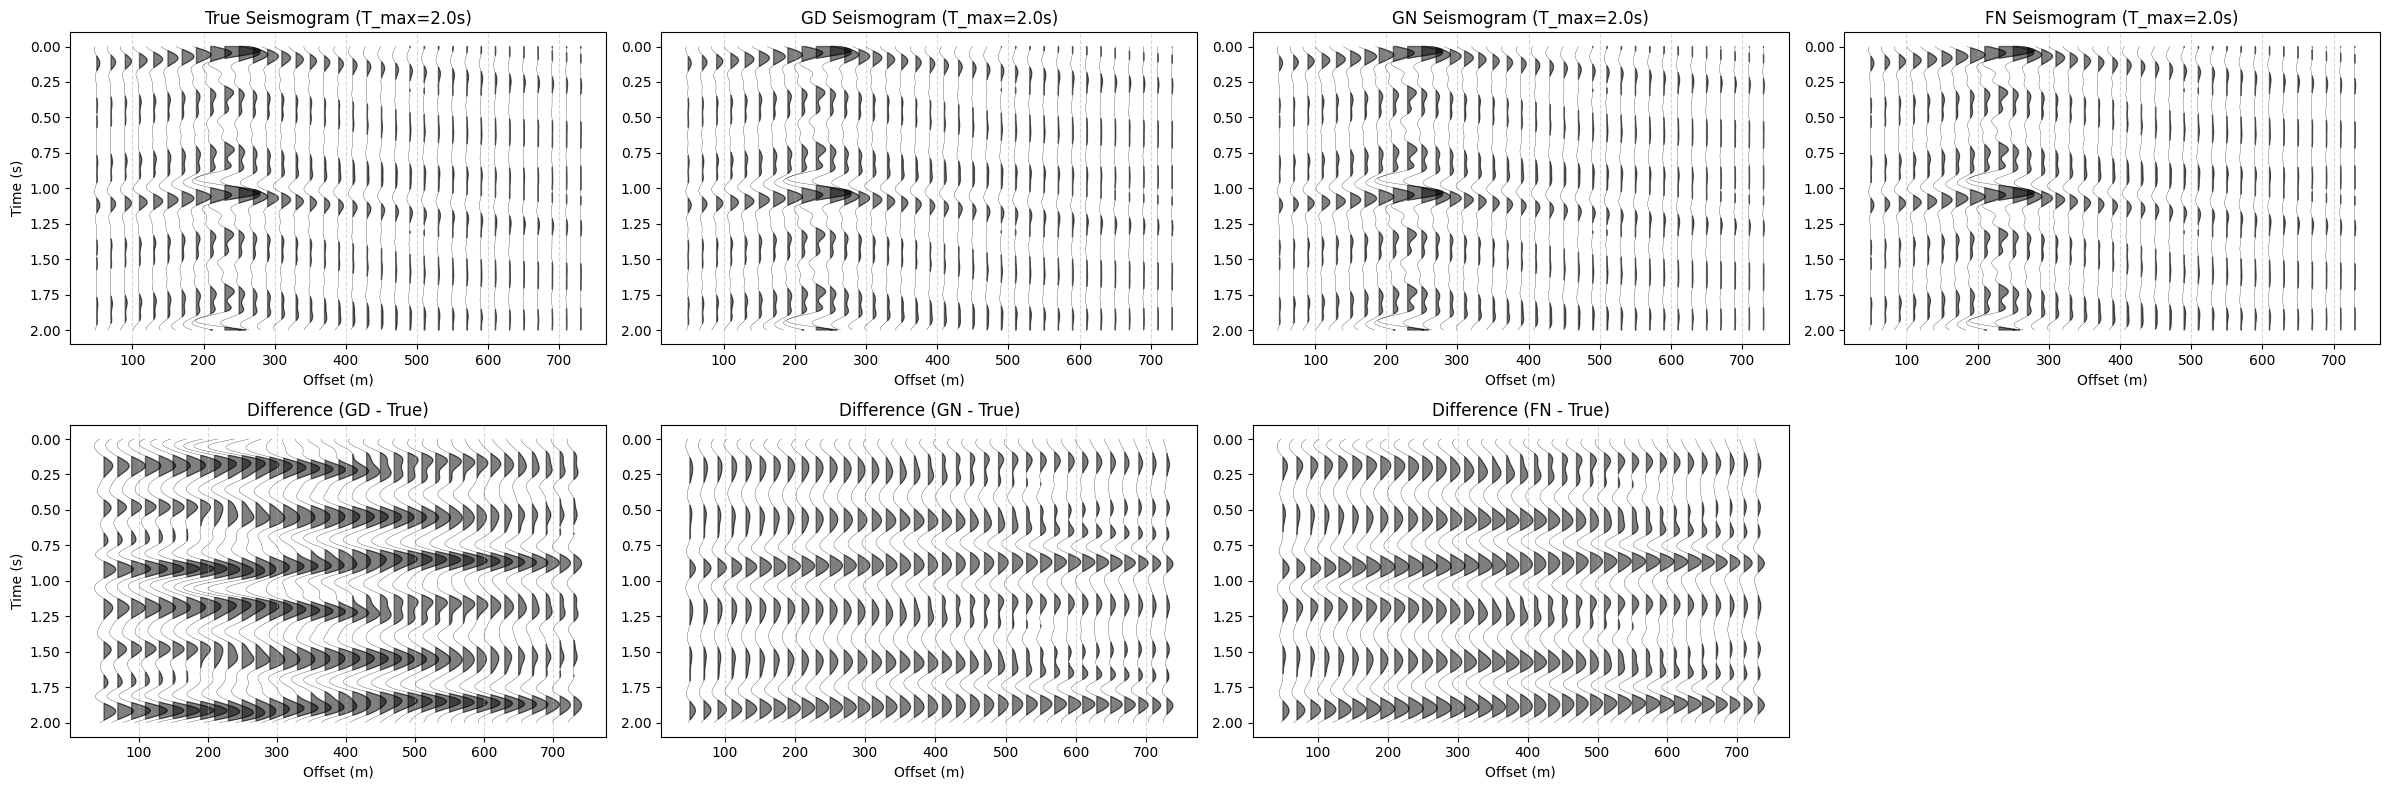

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming seismogram, seismogram_gn, T_max_display, dx, n_rec, rec_x are already defined

plt.figure(figsize=(24, 8)) # Adjust figure size to accommodate more subplots

time_axis = np.linspace(0, T_max_display, seismogram.shape[0])

# Determine a global max amplitude for consistent scaling across all original and recovered seismograms
combined_seismograms = np.concatenate((seismogram, seismogram_gn, seismogram_gd, seismogram_fn))
global_max_amplitude_main = -np.max(np.abs(combined_seismograms))
display_scale_factor_main = (dx * 5) / global_max_amplitude_main

# Calculate all difference seismograms
difference_seismogram_gn = seismogram_gn- seismogram
difference_seismogram_gd = seismogram_gd - seismogram
difference_seismogram_fn = seismogram_fn - seismogram

# Determine a global max amplitude for consistent scaling across all difference seismograms
combined_diff_seismograms = np.concatenate((difference_seismogram_gn, difference_seismogram_gd, difference_seismogram_fn))
global_max_amplitude_diff = -np.max(np.abs(combined_diff_seismograms))
display_scale_factor_diff = (dx * 5) / global_max_amplitude_diff if global_max_amplitude_diff != 0 else 1.0 # Avoid division by zero

# --- Plot 1: True Model Seismogram ---
plt.subplot(2, 4, 1) # 2 rows, 4 columns, first plot
for i in range(0, n_rec, 1):
    trace = seismogram[:, i] * display_scale_factor_main
    plt.plot(rec_x[i]*dx + trace, time_axis, color='black', lw=.2)
    plt.fill_betweenx(time_axis, rec_x[i]*dx, rec_x[i]*dx + trace,
                     where=(trace > 0), color='black', alpha=.5)
plt.gca().invert_yaxis()
plt.title(f"True Seismogram (T_max={T_max_display}s)")
plt.xlabel("Offset (m)")
plt.ylabel("Time (s)")
plt.grid(axis='x', linestyle='--', alpha=0.5)

# --- Plot 2: Recovered Wiggle Plot Seismogram (GD) ---
plt.subplot(2, 4, 2) # 2 rows, 4 columns, second plot
for i in range(0, n_rec, 1):
    trace = seismogram_gd[:, i] * display_scale_factor_main
    plt.plot(rec_x[i]*dx + trace, time_axis, color='black', lw=.2)
    plt.fill_betweenx(time_axis, rec_x[i]*dx, rec_x[i]*dx + trace,
                     where=(trace > 0), color='black', alpha=.5)
plt.gca().invert_yaxis()
plt.title(f"GD Seismogram (T_max={T_max_display}s)")
plt.xlabel("Offset (m)")
plt.grid(axis='x', linestyle='--', alpha=0.5)

# --- Plot 3: Recovered Wiggle Plot Seismogram (GN) ---
plt.subplot(2, 4, 3) # 2 rows, 4 columns, third plot
for i in range(0, n_rec, 1):
    trace = seismogram_gn[:, i] * display_scale_factor_main
    plt.plot(rec_x[i]*dx + trace, time_axis, color='black', lw=.2)
    plt.fill_betweenx(time_axis, rec_x[i]*dx, rec_x[i]*dx + trace,
                     where=(trace > 0), color='black', alpha=.5)
plt.gca().invert_yaxis()
plt.title(f"GN Seismogram (T_max={T_max_display}s)")
plt.xlabel("Offset (m)")
plt.grid(axis='x', linestyle='--', alpha=0.5)

# --- Plot 4: Recovered Wiggle Plot Seismogram (FN) ---
plt.subplot(2, 4, 4) # 2 rows, 4 columns, fourth plot
for i in range(0, n_rec, 1):
    trace = seismogram_fn[:, i] * display_scale_factor_main
    plt.plot(rec_x[i]*dx + trace, time_axis, color='black', lw=.2)
    plt.fill_betweenx(time_axis, rec_x[i]*dx, rec_x[i]*dx + trace,
                     where=(trace > 0), color='black', alpha=.5)
plt.gca().invert_yaxis()
plt.title(f"FN Seismogram (T_max={T_max_display}s)")
plt.xlabel("Offset (m)")
plt.grid(axis='x', linestyle='--', alpha=0.5)

# --- Plot 5: Difference Seismogram (GD - True) ---
plt.subplot(2, 4, 5) # 2 rows, 4 columns, fifth plot
for i in range(0, n_rec, 1):
    trace = difference_seismogram_gd[:, i] * display_scale_factor_diff
    plt.plot(rec_x[i]*dx + trace, time_axis, color='black', lw=.2)
    plt.fill_betweenx(time_axis, rec_x[i]*dx, rec_x[i]*dx + trace,
                     where=(trace > 0), color='black', alpha=.5)
plt.gca().invert_yaxis()
plt.title(f"Difference (GD - True)")
plt.xlabel("Offset (m)")
plt.ylabel("Time (s)")
plt.grid(axis='x', linestyle='--', alpha=0.5)

# --- Plot 6: Difference Seismogram (GN - True) ---
plt.subplot(2, 4, 6) # 2 rows, 4 columns, sixth plot
for i in range(0, n_rec, 1):
    trace = difference_seismogram_gn[:, i] * display_scale_factor_diff
    plt.plot(rec_x[i]*dx + trace, time_axis, color='black', lw=.2)
    plt.fill_betweenx(time_axis, rec_x[i]*dx, rec_x[i]*dx + trace,
                     where=(trace > 0), color='black', alpha=.5)
plt.gca().invert_yaxis()
plt.title(f"Difference (GN - True)")
plt.xlabel("Offset (m)")
plt.grid(axis='x', linestyle='--', alpha=0.5)

# --- Plot 7: Difference Seismogram (FN - True) ---
plt.subplot(2, 4, 7) # 2 rows, 4 columns, seventh plot
for i in range(0, n_rec, 1):
    trace = difference_seismogram_fn[:, i] * display_scale_factor_diff
    plt.plot(rec_x[i]*dx + trace, time_axis, color='black', lw=.2)
    plt.fill_betweenx(time_axis, rec_x[i]*dx, rec_x[i]*dx + trace,
                     where=(trace > 0), color='black', alpha=.5)
plt.gca().invert_yaxis()
plt.title(f"Difference (FN - True)")
plt.xlabel("Offset (m)")
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
print(f"Maximum absolute difference between seismogram and recovered seismogram: {np.max(np.abs(seismogram_r - seismogram))}")
print(f"Are seismogram and seismogram_r numerically identical? {np.array_equal(seismogram, seismogram_r)}")

Maximum absolute difference between seismogram and recovered seismogram: 0.0015648484450232949
Are seismogram and seismogram_r numerically identical? False


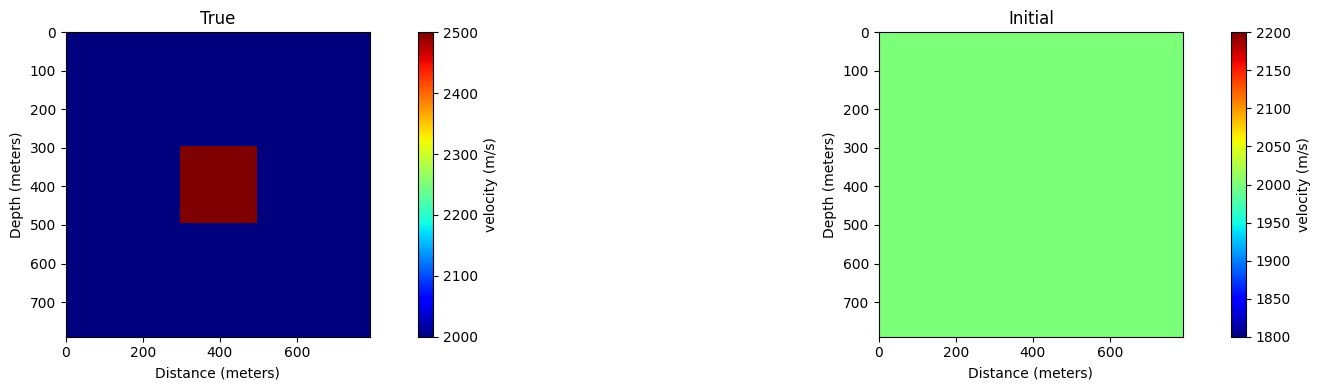

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(18,4))

plt.subplot(121)
plt.title("True")
plt.imshow(c_true,cmap='jet',extent=model_extent)
plt.colorbar(label="velocity (m/s)")
plt.xlabel("Distance (meters)")
plt.ylabel("Depth (meters)")

plt.subplot(122)
plt.title("Initial")
plt.imshow(c_init,cmap='jet',extent=model_extent)
plt.colorbar(label="velocity (m/s)")
plt.xlabel("Distance (meters)")
plt.ylabel("Depth (meters)")

plt.tight_layout()
plt.show()

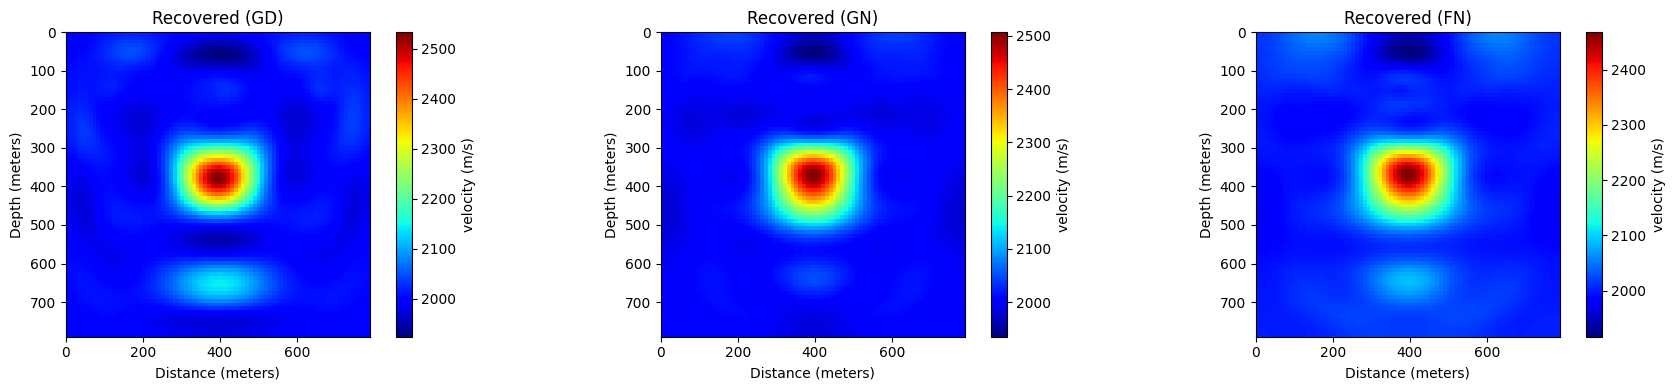

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18,4))


plt.subplot(131)
plt.title("Recovered (GD)")
plt.imshow(1/np.sqrt(m_gd),cmap='jet',extent=model_extent)
plt.colorbar(label="velocity (m/s)")
plt.xlabel("Distance (meters)")
plt.ylabel("Depth (meters)")

plt.subplot(132)
plt.title("Recovered (GN)")
plt.imshow(1/np.sqrt(m_gn),cmap='jet',extent=model_extent)
plt.colorbar(label="velocity (m/s)")
plt.xlabel("Distance (meters)")
plt.ylabel("Depth (meters)")

plt.subplot(133)
plt.title("Recovered (FN)")
plt.imshow(1/np.sqrt(m_fn),cmap='jet',extent=model_extent)
plt.colorbar(label="velocity (m/s)")
plt.xlabel("Distance (meters)")
plt.ylabel("Depth (meters)")

plt.tight_layout()
plt.show()



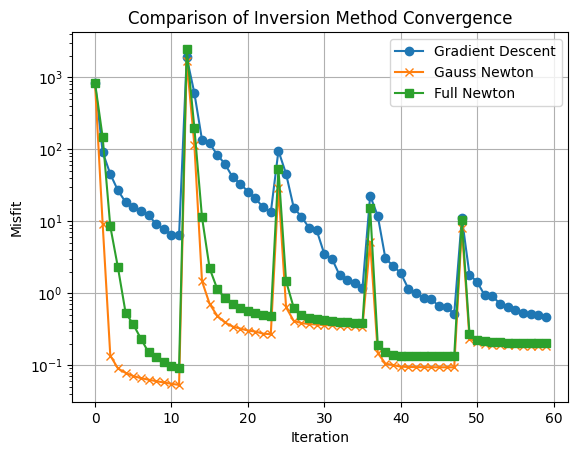

In [ ]:
plt.figure()
plt.semilogy(misfits_gd,'-o', label='Gradient Descent')
plt.semilogy(misfits_gn,'-x', label='Gauss Newton')
plt.semilogy(misfits_fn,'-s', label='Full Newton')
plt.xlabel("Iteration")
plt.ylabel("Misfit")
plt.title("Comparison of Inversion Method Convergence")
plt.grid()
plt.legend()
plt.show()

--- Gradient Descent Iteration Profiles ---

===== Frequency: 3 Hz =====
Iter: 1 Misfit: 120.42638878035822

===== Frequency: 4 Hz =====
Iter: 1 Misfit: 278.07562985093125

===== Frequency: 5 Hz =====
Iter: 1 Misfit: 106.11262147440338

===== Frequency: 6 Hz =====
Iter: 1 Misfit: 32.23050144160312

===== Frequency: 7 Hz =====
Iter: 1 Misfit: 18.470402117263305

===== Frequency: 3 Hz =====
Iter: 1 Misfit: 120.42638878035822
Iter: 2 Misfit: 9.929440142133876

===== Frequency: 4 Hz =====
Iter: 1 Misfit: 280.41139932441865
Iter: 2 Misfit: 223.9373606621777

===== Frequency: 5 Hz =====
Iter: 1 Misfit: 97.8048750719822
Iter: 2 Misfit: 25.86383654155896

===== Frequency: 6 Hz =====
Iter: 1 Misfit: 17.911118266237523
Iter: 2 Misfit: 10.913983830936907

===== Frequency: 7 Hz =====
Iter: 1 Misfit: 12.916030832567767
Iter: 2 Misfit: 9.126583368483063

===== Frequency: 3 Hz =====
Iter: 1 Misfit: 120.42638878035822
Iter: 2 Misfit: 9.929440142133876
Iter: 3 Misfit: 7.345377071628246

===== Frequency

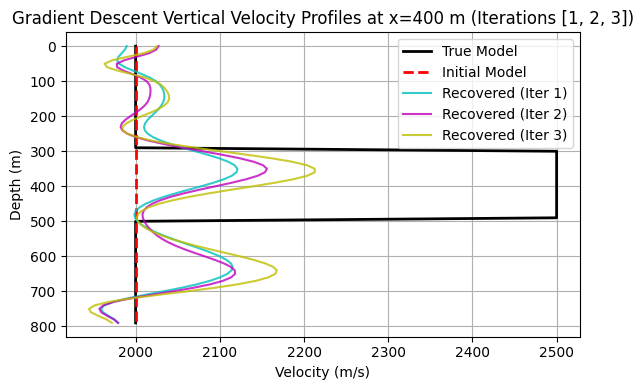


--- Gauss Newton Iteration Profiles ---

===== Frequency: 3 Hz =====
Iteration: 1 Misfit: 120.42638878035822 beta: 41.57852934624708

===== Frequency: 4 Hz =====
Iteration: 1 Misfit: 249.9400321506319 beta: 23.387922757263983

===== Frequency: 5 Hz =====
Iteration: 1 Misfit: 26.07179719935937 beta: 14.968270564648948

===== Frequency: 6 Hz =====
Iteration: 1 Misfit: 20.14751683042552 beta: 10.39463233656177

===== Frequency: 7 Hz =====
Iteration: 1 Misfit: 7.39941749792062 beta: 7.63687273706579

===== Frequency: 3 Hz =====
Iteration: 1 Misfit: 120.42638878035822 beta: 41.57852934624708
Iteration: 2 Misfit: 1.3575790083737576 beta: 20.78926467312354

===== Frequency: 4 Hz =====
Iteration: 1 Misfit: 237.2590214328429 beta: 23.387922757263983
Iteration: 2 Misfit: 13.322833620151352 beta: 11.693961378631991

===== Frequency: 5 Hz =====
Iteration: 1 Misfit: 13.752826029268013 beta: 14.968270564648948
Iteration: 2 Misfit: 0.6057846263991754 beta: 7.484135282324474

===== Frequency: 6 Hz ==

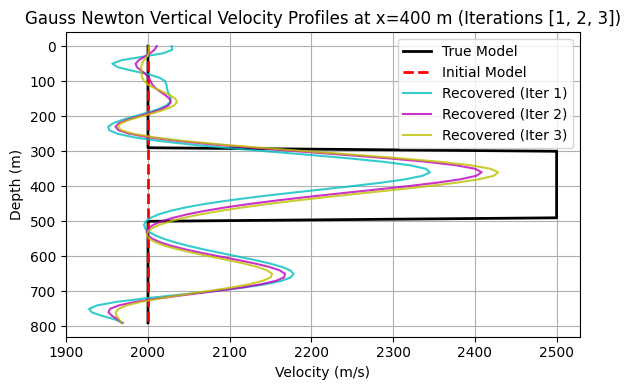


--- Full Newton Iteration Profiles ---

===== Frequency: 3 Hz =====
Iter: 1 Misfit: 120.42638878035822 beta: 374.2067641162237

===== Frequency: 4 Hz =====
Iter: 1 Misfit: 242.78627114725077 beta: 374.2067641162237

===== Frequency: 5 Hz =====
Iter: 1 Misfit: 25.288751082532354 beta: 374.2067641162237

===== Frequency: 6 Hz =====
Iter: 1 Misfit: 18.53462470881854 beta: 374.2067641162237

===== Frequency: 7 Hz =====
Iter: 1 Misfit: 7.308184230119289 beta: 374.2067641162237

===== Frequency: 3 Hz =====
Iter: 1 Misfit: 120.42638878035822 beta: 374.2067641162237
Iter: 2 Misfit: 3.989894255166337 beta: 187.10338205811186

===== Frequency: 4 Hz =====
Iter: 1 Misfit: 250.92842420528763 beta: 374.2067641162237
Iter: 2 Misfit: 14.51225909340243 beta: 187.10338205811186

===== Frequency: 5 Hz =====
Iter: 1 Misfit: 16.420580456493703 beta: 374.2067641162237
Iter: 2 Misfit: 1.1221461487810334 beta: 187.10338205811186

===== Frequency: 6 Hz =====
Iter: 1 Misfit: 19.878857480235073 beta: 374.206764

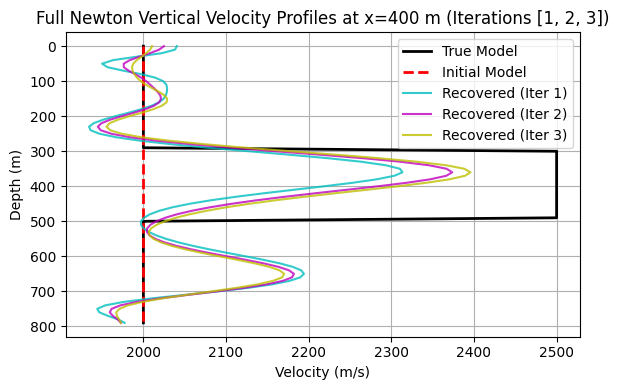

In [ ]:
import matplotlib.pyplot as plt

def plot_velocity_profile_iteration(iteration_num, m_recovered, c_true, c_init, nx, nz, dx, title_prefix):
    x_profile_idx = nx // 2
    c_true_profile = c_true[:, x_profile_idx]
    c_init_profile = c_init[:, x_profile_idx]
    c_recovered_profile = 1 / np.sqrt(m_recovered[:, x_profile_idx])
    depth = np.arange(nz) * dz

    plt.figure(figsize=(6, 4))
    plt.plot(c_true_profile, depth, 'k-', linewidth=2, label='True Model')
    plt.plot(c_init_profile, depth, 'r--', label='Initial Model')
    plt.plot(c_recovered_profile, depth, 'b-', alpha=0.7, label=f'Recovered (Iter {iteration_num})')
    plt.xlabel('Velocity (m/s)')
    plt.ylabel('Depth (m)')
    plt.title(f'{title_prefix} Vertical Velocity Profile at x={x_profile_idx * dx} m (Iteration {iteration_num})')
    plt.gca().invert_yaxis() # Invert y-axis to represent depth
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_comparison_profile(method_name, m_recovered_list, c_true, c_init, nx, nz, dx, iterations_to_plot):
    x_profile_idx = nx // 2
    c_true_profile = c_true[:, x_profile_idx]
    c_init_profile = c_init[:, x_profile_idx]
    depth = np.arange(nz) * dz

    plt.figure(figsize=(6, 4))
    plt.plot(c_true_profile, depth, 'k-', linewidth=2, label='True Model')
    plt.plot(c_init_profile, depth, 'r--', linewidth=2, label='Initial Model')

    colors = ['c', 'm', 'y', 'g', 'b'] # More colors for iterations
    for i, m_recovered_iter in enumerate(m_recovered_list):
        c_recovered_profile = 1 / np.sqrt(m_recovered_iter[:, x_profile_idx])
        plt.plot(c_recovered_profile, depth, color=colors[i % len(colors)], linestyle='-', alpha=0.8, label=f'Recovered (Iter {iterations_to_plot[i]})')

    plt.xlabel('Velocity (m/s)')
    plt.ylabel('Depth (m)')
    plt.title(f'{method_name} Vertical Velocity Profiles at x={x_profile_idx * dx} m (Iterations {iterations_to_plot})')
    plt.gca().invert_yaxis() # Invert y-axis to represent depth
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


print("--- Gradient Descent Iteration Profiles ---")
# Re-running for GD to collect all iterations
m_gd_iters = []
iterations_gd = [1, 2, 3]
for i in iterations_gd:
    m_gd_iter, _ = Gradient(c_init, frequencies, d_obs,
                         P, rec_idx,
                        src_x, src_z,
                        nx, nz, n, idx,
                        dx,dz,npml,vmax,
                        n_iterations=i)
    m_gd_iters.append(m_gd_iter)
plot_comparison_profile("Gradient Descent", m_gd_iters, c_true, c_init, nx, nz, dx, iterations_gd)

print("\n--- Gauss Newton Iteration Profiles ---")
m_gn_iters = []
iterations_gn = [1, 2, 3]
for i in iterations_gn:
    m_gn_iter, _ = Gauss_newton(c_init, frequencies, d_obs,
                         P, rec_idx,
                        src_x, src_z,
                        nx, nz, n, idx,
                        dx,dz,npml,vmax,
                        beta0,
                        n_iterations=i,
                        cg_maxiter=10)
    m_gn_iters.append(m_gn_iter)
plot_comparison_profile("Gauss Newton", m_gn_iters, c_true, c_init, nx, nz, dx, iterations_gn)

print("\n--- Full Newton Iteration Profiles ---")
m_fn_iters = []
iterations_fn = [1, 2, 3]
for i in iterations_fn:
    m_fn_iter, _ = Full_newton(c_init, frequencies, d_obs,
                           P, rec_idx,
                           src_x, src_z,
                           nx, nz, n, idx,
                           dx,dz,npml,vmax,
                           beta0,
                           n_iterations=i,
                           minres_maxiter=10)
    m_fn_iters.append(m_fn_iter)
plot_comparison_profile("Full Newton", m_fn_iters, c_true, c_init, nx, nz, dx, iterations_fn)


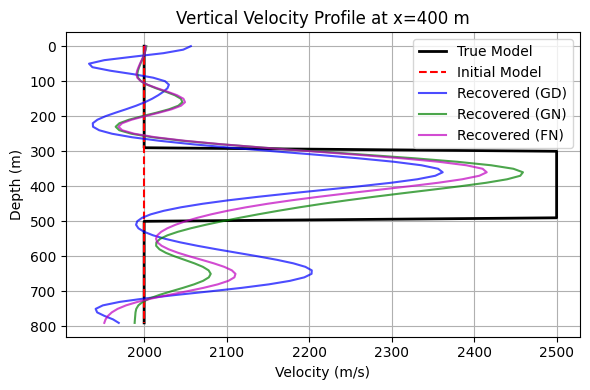

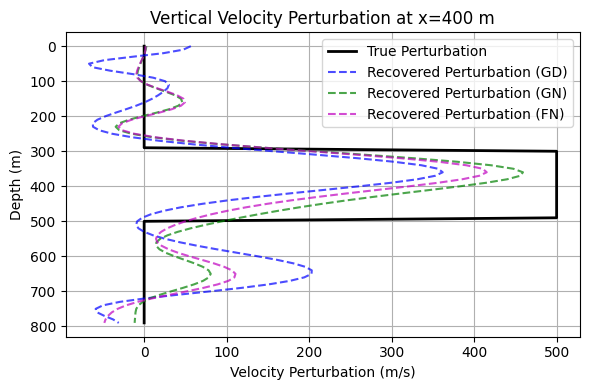

In [ ]:
# Choose a vertical profile (e.g., at the center of the model)
x_profile_idx = nx // 2

# Extract true and initial velocity profiles
c_true_profile = c_true[:, x_profile_idx]
c_init_profile = c_init[:, x_profile_idx]

# Convert recovered slowness-squared models to velocity profiles
c_gd_profile = 1 / np.sqrt(m_gd[:, x_profile_idx])
c_gn_profile = 1 / np.sqrt(m_gn[:, x_profile_idx])
c_fn_profile = 1 / np.sqrt(m_fn[:, x_profile_idx])

# Calculate velocity perturbations relative to the initial model
delta_c_true = c_true_profile - c_init_profile
delta_c_gd = c_gd_profile - c_init_profile
delta_c_gn = c_gn_profile - c_init_profile
delta_c_fn = c_fn_profile - c_init_profile

# Create depth axis
depth = np.arange(nz) * dz

# Plotting Velocity Profiles
plt.figure(figsize=(6, 4))
plt.plot(c_true_profile, depth, 'k-', linewidth=2, label='True Model')
plt.plot(c_init_profile, depth, 'r--', label='Initial Model')
plt.plot(c_gd_profile, depth, 'b-', alpha=0.7, label='Recovered (GD)')
plt.plot(c_gn_profile, depth, 'g-', alpha=0.7, label='Recovered (GN)')
plt.plot(c_fn_profile, depth, 'm-', alpha=0.7, label='Recovered (FN)')
plt.xlabel('Velocity (m/s)')
plt.ylabel('Depth (m)')
plt.title(f'Vertical Velocity Profile at x={x_profile_idx * dx} m')
plt.gca().invert_yaxis() # Invert y-axis to represent depth
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plotting Velocity Perturbations
plt.figure(figsize=(6, 4))
plt.plot(delta_c_true, depth, 'k-', linewidth=2, label='True Perturbation')
plt.plot(delta_c_gd, depth, 'b--', alpha=0.7, label='Recovered Perturbation (GD)')
plt.plot(delta_c_gn, depth, 'g--', alpha=0.7, label='Recovered Perturbation (GN)')
plt.plot(delta_c_fn, depth, 'm--', alpha=0.7, label='Recovered Perturbation (FN)')
plt.xlabel('Velocity Perturbation (m/s)')
plt.ylabel('Depth (m)')
plt.title(f'Vertical Velocity Perturbation at x={x_profile_idx * dx} m')
plt.gca().invert_yaxis() # Invert y-axis to represent depth
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print(f"Final Misfit for Gradient Descent (GD): {misfits_gd[-1]:.4f}")
print(f"Final Misfit for Gauss Newton (GN): {misfits_gn[-1]:.4f}")
print(f"Final Misfit for Full Newton (FN): {misfits_fn[-1]:.4f}")

Final Misfit for Gradient Descent (GD): 0.4427
Final Misfit for Gauss Newton (GN): 0.0561
Final Misfit for Full Newton (FN): 0.0621


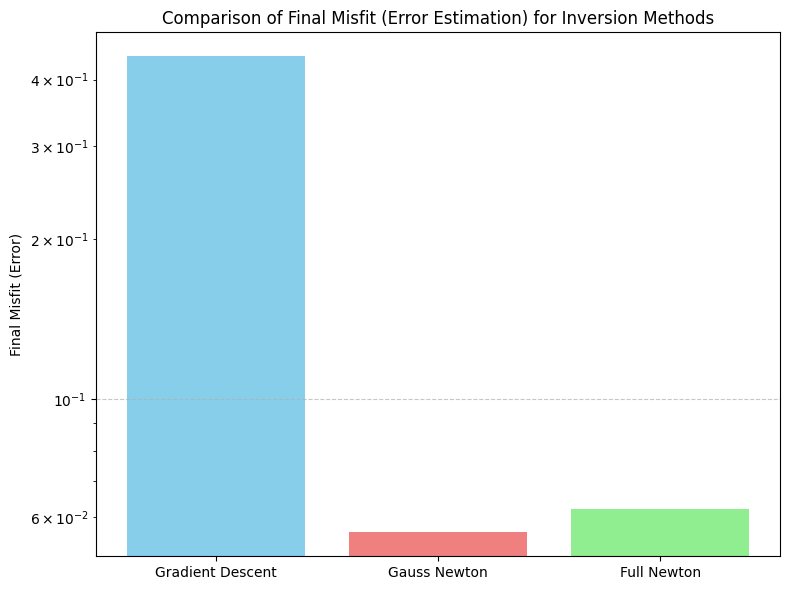

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract final misfit values
final_misfits = {
    'Gradient Descent': misfits_gd[-1],
    'Gauss Newton': misfits_gn[-1],
    'Full Newton': misfits_fn[-1]
}

methods = list(final_misfits.keys())
values = list(final_misfits.values())

plt.figure(figsize=(8, 6))
plt.bar(methods, values, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.ylabel('Final Misfit (Error)')
plt.title('Comparison of Final Misfit (Error Estimation) for Inversion Methods')
plt.yscale('log') # Use a log scale due to the large difference in values
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()